<a href="https://colab.research.google.com/github/Daniel-Xkan/potts_model_test/blob/main/delta_E_D148B.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### import and initialize the paramters for position and amino acid for mutation


In [55]:
import numpy as np

J = np.load('J.npy')
# with open('in.reduce4.seq', 'r') as f:
#     sequence = f.read().strip()

amino_acids = ['A', 'B', 'C', 'D']

position = 148
old_amino_acid = 'D'
new_amino_acid = 'B'

total_energy_change = 0
# Split the sequence into a list of sequences by rows
# sequence_list = sequence.split('\n')

# Print the first few sequences to verify
# print(sequence_list[0])  # Display the first 5 sequences

In [56]:
# print(len(sequence_list[0]))

In [57]:
J
print(J.shape)

(34453, 16)


In [58]:
# print(f"0,148: {sequence_list[0][147]}")
# print(f"1,148: {sequence_list[1][147]}")

In [59]:
#dictionary of J matrix
J_dict = {}

row = 0
for pos1 in range(1, 264):
    for pos2 in range(pos1 + 1, 264):

        for i, aa1 in enumerate(['A', 'B', 'C', 'D']):
            for j, aa2 in enumerate(['A', 'B', 'C', 'D']):
                col = i*4+j


                J_dict[(pos1, pos2, aa1, aa2)] = J[row, col]
                J_dict[(pos2, pos1, aa2, aa1)] = J[row, col]
                if pos1  == 140 and pos2 == 148:
                    print(f"Row {row}: J[{row}, {col}] = {J[row, col]} for positions ({pos1}, {pos2}) with amino acids ({aa1}, {aa2})")
        row += 1

print(f"Dictionary created with {len(J_dict)} entries")

Row 26834: J[26834, 0] = -1.3829545974731445 for positions (140, 148) with amino acids (A, A)
Row 26834: J[26834, 1] = 1.0480310916900635 for positions (140, 148) with amino acids (A, B)
Row 26834: J[26834, 2] = -0.6103933453559875 for positions (140, 148) with amino acids (A, C)
Row 26834: J[26834, 3] = 0.991757869720459 for positions (140, 148) with amino acids (A, D)
Row 26834: J[26834, 4] = 0.5708320736885071 for positions (140, 148) with amino acids (B, A)
Row 26834: J[26834, 5] = 0.3530581593513489 for positions (140, 148) with amino acids (B, B)
Row 26834: J[26834, 6] = -0.2805359661579132 for positions (140, 148) with amino acids (B, C)
Row 26834: J[26834, 7] = -0.6035533547401428 for positions (140, 148) with amino acids (B, D)
Row 26834: J[26834, 8] = 0.6180163621902466 for positions (140, 148) with amino acids (C, A)
Row 26834: J[26834, 9] = 1.1907997131347656 for positions (140, 148) with amino acids (C, B)
Row 26834: J[26834, 10] = 0.6925382614135742 for positions (140, 14

sanity check: 34191 (262C2) *16 *2 = 1094112

In [60]:
print( J_dict.get((0, 1, 'A', 'A'))) #shound be None
print( J_dict.get((1, 2, 'A', 'A')))
print( J_dict.get((1, 3, 'A', 'A')))
print( J_dict.get((261, 262, 'D', 'D')))
matching_keys = [key for key, value in J_dict.items() if abs(value - 0.022138428) < 0]
print(f"Keys with value 0.022138428: {matching_keys}")

None
-0.006689224
-0.04789487
0.016719325
Keys with value 0.022138428: []


In [ ]:

with open('in.consensus.reduce4.seq', 'r') as f:
    sequence_list = f.read().strip().split('\n')

FileNotFoundError: [Errno 2] No such file or directory: 'data/in.consensus.reduce4.seq'

other pos: 148 == 148:
    continue
other pos: 149 != 148:
    sequence_list[0][148]

In [ ]:
# E(old_amino_acid)
energy_old = 0
for other_pos in range(1, 264):
    if other_pos == position:
        continue
    other_aa = sequence_list[0][other_pos - 1]  # Access the first sequence in sequence_list
    energy_old += J_dict.get((position, other_pos, old_amino_acid, other_aa), 0)

# E(new_amino_acid)
energy_new = 0
for other_pos in range(1, 264):
    if other_pos == position:
        continue
    other_aa = sequence_list[0][other_pos - 1]  # Access the first sequence in sequence_list
    energy_new += J_dict.get((position, other_pos, new_amino_acid, other_aa), 0)

print(f"E({old_amino_acid}) at {position}: {energy_old}")
print(f"E({new_amino_acid}) at {position}: {energy_new}")
print(f"Delta E for {old_amino_acid}{position}{new_amino_acid}: {energy_old - energy_new}")

E(D) at 148: -5.166963144816691
E(B) at 148: -12.54862233879976
Delta E for D148B: 7.381659193983069


In [ ]:
# # Read the sequence list from the file
# with open('in.nl43.reduce4.seq', 'r') as f:
#     sequence_list = f.read().strip().split('\n')

# # Print the first few sequences to verify
# print(sequence_list[:5])  # Display the first 5 sequences

In [ ]:
delta_e_list = []

for seq in sequence_list:
    # E(old_amino_acid)
    energy_old = 0
    for other_pos in range(1, 264):
        if other_pos == position:
            continue
        other_aa = seq[other_pos - 1]  # Access the current sequence
        energy_old += J_dict.get((position, other_pos, old_amino_acid, other_aa), 0)

    # E(new_amino_acid)
    energy_new = 0
    for other_pos in range(1, 264):
        if other_pos == position:
            continue
        other_aa = seq[other_pos - 1]  # Access the current sequence
        energy_new += J_dict.get((position, other_pos, new_amino_acid, other_aa), 0)

    # Calculate delta E and append to the list
    delta_e = energy_old - energy_new
    delta_e_list.append(delta_e)

print(f"Delta E list for D148B: {delta_e_list}")

Delta E list for D148B: [7.381659193983069, -5.939129250036785, 4.80686296345084, 4.668665352364769, -7.701221401715884, -7.6108291360142175, -7.822749363636831, -5.870150968345115, -4.374572853936115, -6.0032507273426745, -8.835149103688309, -5.205967851827154, 6.062264221807709, -3.7019284832349513, -3.148473666893551, -3.7019284832349513, -3.7019284832349513, -3.7019284832349513, -4.322970022825757, -4.322970022825757, 4.093291732104262, -5.1859060986025725, -6.777112923009554, -4.808700818481157, -4.808700818481157, -6.857479978265474, -6.8634292445203755, -4.570201877417276, -4.570201877417276, 3.7660302036383655, -3.340742273168871, -5.198929043399403, 2.8277328033873346, 5.796776339499047, -3.9433051393425558, -3.9433051393425558, 4.565486307343235, -4.9031483530125115, -4.118897898035357, -6.763658927666256, -7.351222108962247, -4.456803487060824, -4.380814203439513, -4.456803487060824, -4.58935200367705, -4.58935200367705, -4.554549460212002, -4.346032802859554, -5.32424320877

what differentiate the lowest

why one has some mutations and some has other.

In [ ]:
highest_delta_e = max(delta_e_list)
lowest_delta_e = min(delta_e_list)

print(f"Highest Delta E: {highest_delta_e}")
print(f"Lowest Delta E: {lowest_delta_e}")

Highest Delta E: 8.512258228467545
Lowest Delta E: -10.259426908014575


Goal: find what sequences caused the difference between the highest and lowest delta E:
TODO: for each position of the two sequences, calculate its value for that position, and blue if negative and red if positive, the y axis is the intensity of the value of d to b in that position. pot in on graph

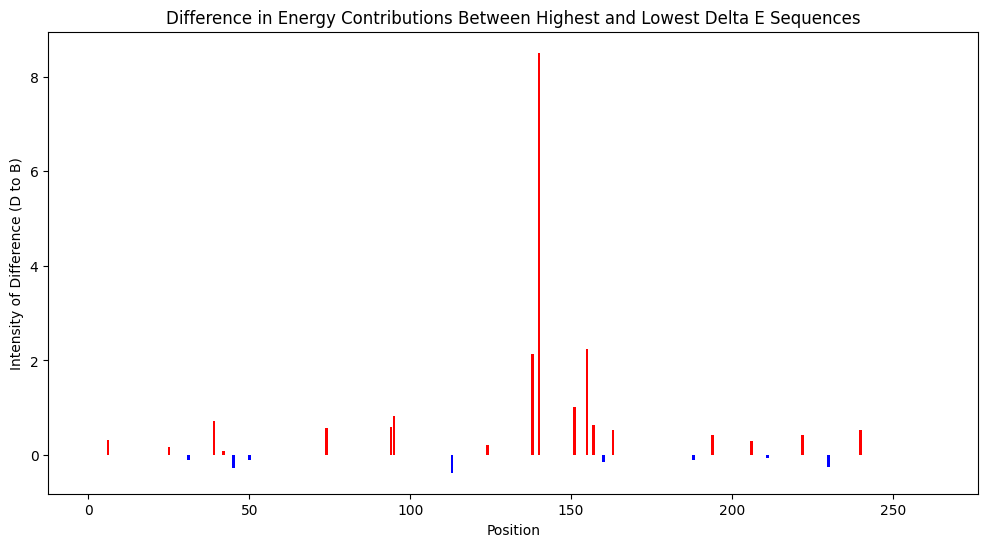

In [ ]:
import matplotlib.pyplot as plt

# Find the sequences corresponding to the highest and lowest delta E
highest_delta_e_index = delta_e_list.index(highest_delta_e)
lowest_delta_e_index = delta_e_list.index(lowest_delta_e)

highest_sequence = sequence_list[highest_delta_e_index]
lowest_sequence = sequence_list[lowest_delta_e_index]

# Calculate the difference in energy contributions for each position
position_values = []
colors = []

for pos in range(1, 264):

    aa_high = highest_sequence[pos - 1]
    aa_low = lowest_sequence[pos - 1]
    value_high_new = J_dict.get((position, pos, new_amino_acid, aa_high), 0)
    value_high_old = J_dict.get((position, pos, old_amino_acid, aa_high), 0)
    value_low_new = J_dict.get((position, pos, new_amino_acid, aa_low), 0)
    value_low_old = J_dict.get((position, pos, old_amino_acid, aa_low), 0)
    difference = (value_high_old - value_high_new) - (value_low_old - value_low_new)
    position_values.append(difference)
    colors.append('blue' if difference < 0 else 'red')

# Plot the results
plt.figure(figsize=(12, 6))
plt.bar(range(1, 264), position_values, color=colors)
plt.xlabel('Position')
plt.ylabel('Intensity of Difference (D to B)')
plt.title('Difference in Energy Contributions Between Highest and Lowest Delta E Sequences')
plt.show()

In [ ]:
# Sum all differences
sum_of_differences = sum(position_values)

# Calculate the difference between highest and lowest delta E
calculated_difference = highest_delta_e - lowest_delta_e

# Print the results for sanity check
print(f"Sum of all differences: {sum_of_differences}")
print(f"Calculated difference (highest - lowest): {calculated_difference}")
print(f"Sanity check passed: {abs(sum_of_differences - calculated_difference) < 1e-6}")

Sum of all differences: 18.771684676408768
Calculated difference (highest - lowest): 18.77168513648212
Sanity check passed: True


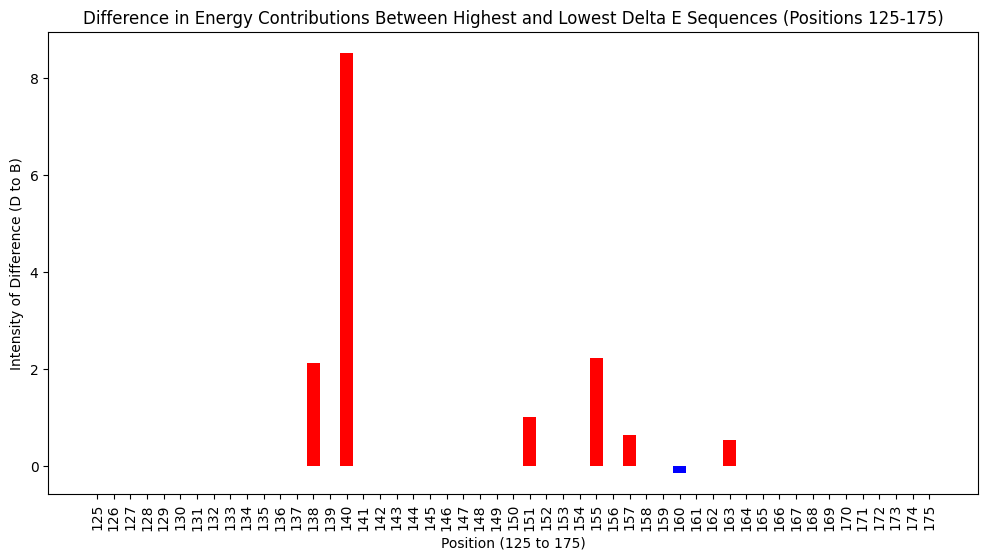

In [ ]:
# Filter the data for positions 125 to 175
filtered_positions = range(125, 176)
filtered_values = position_values[124:175]  # Adjusting for 0-based indexing
filtered_colors = colors[124:175]

# Plot the results
plt.figure(figsize=(12, 6))
plt.bar(filtered_positions, filtered_values, color=filtered_colors)
plt.xlabel('Position (125 to 175)')
plt.ylabel('Intensity of Difference (D to B)')
plt.title('Difference in Energy Contributions Between Highest and Lowest Delta E Sequences (Positions 125-175)')
plt.xticks(filtered_positions, rotation=90)  # Rotate x-axis labels for clarity
plt.show()

In [ ]:
# Fix position to 140
position = 148
pos = 140


# Iterate over positions and calculate energy values
aa_high = highest_sequence[pos - 1]
aa_low = lowest_sequence[pos - 1]
value_high_new = J_dict.get((position, pos, new_amino_acid, aa_high), 0)
value_high_old = J_dict.get((position, pos, old_amino_acid, aa_high), 0)
value_low_new = J_dict.get((position, pos, new_amino_acid, aa_low), 0)
value_low_old = J_dict.get((position, pos, old_amino_acid, aa_low), 0)


# Print the calculated values with more details
print(f"Position: {pos}")
print(f"Amino Acid at High Sequence: {aa_high}")
print(f"Amino Acid at Low Sequence: {aa_low}")
print(f"High New E ({new_amino_acid}): {value_high_new}")
print(f"High Old E ({old_amino_acid}): {value_high_old}")
print(f"Low New E ({new_amino_acid}): {value_low_new}")
print(f"Low Old E ({old_amino_acid}): {value_low_old}")


Position: 140
Amino Acid at High Sequence: D
Amino Acid at Low Sequence: C
High New E (B): -2.555969476699829
High Old E (D): 2.1417648792266846
Low New E (B): 1.1907997131347656
Low Old E (D): -2.6202573776245117


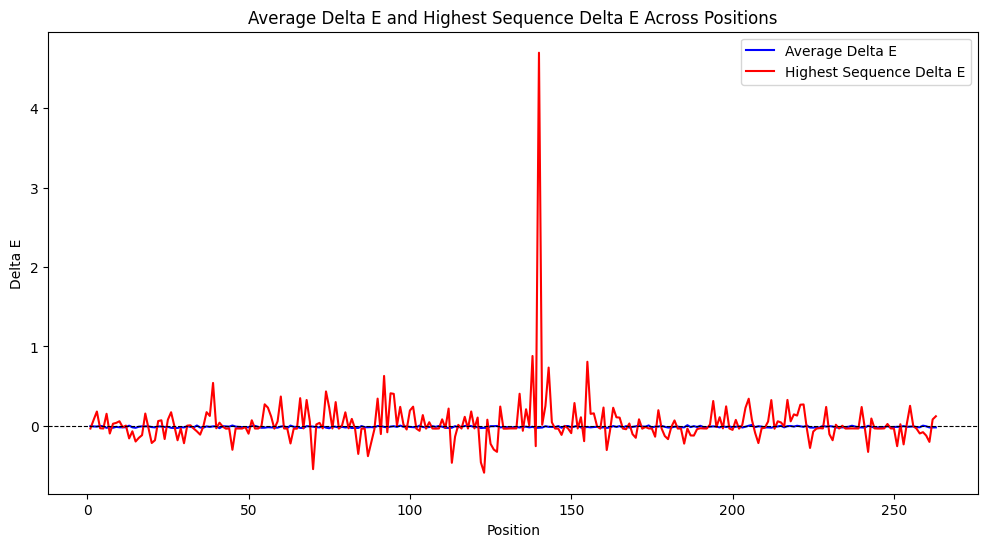

In [ ]:
# Calculate the average delta E for all positions
average_delta_e = [sum(delta_e_list[i::263]) / len(sequence_list) for i in range(263)]

# Calculate the delta E for the highest sequence
highest_sequence_delta_e = []
for pos in range(1, 264):
    other_aa = highest_sequence[pos - 1]
    delta_e = J_dict.get((position, pos, old_amino_acid, other_aa), 0)- J_dict.get((position, pos, new_amino_acid, other_aa), 0)
    highest_sequence_delta_e.append(delta_e)

# Plot the results
plt.figure(figsize=(12, 6))
plt.plot(range(1, 264), average_delta_e, label='Average Delta E', color='blue')
plt.plot(range(1, 264), highest_sequence_delta_e, label='Highest Sequence Delta E', color='red')
plt.axhline(0, color='black', linestyle='--', linewidth=0.8)  # Add a horizontal line at y=0
plt.xlabel('Position')
plt.ylabel('Delta E')
plt.title('Average Delta E and Highest Sequence Delta E Across Positions')
plt.legend()
plt.show()

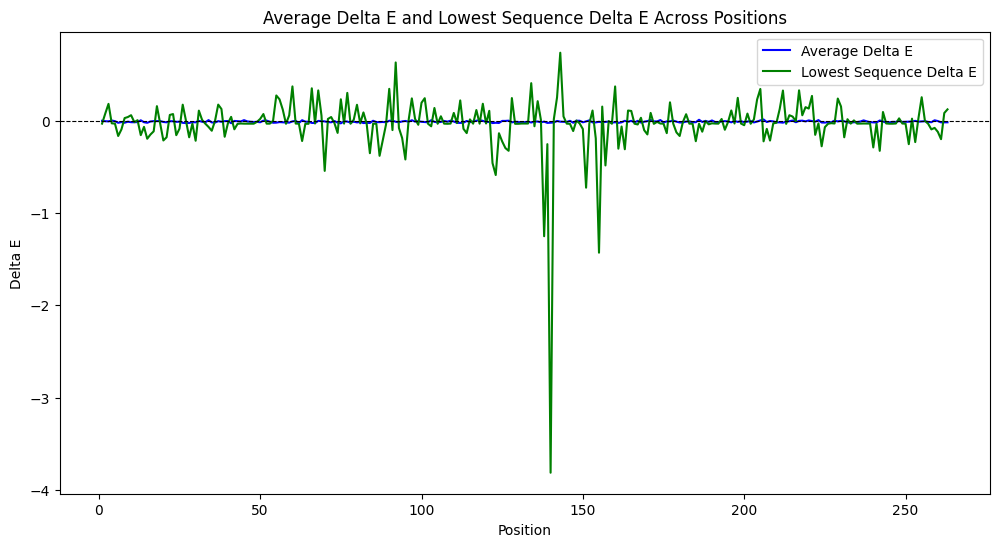

In [ ]:
# Calculate the delta E for the lowest sequence
lowest_sequence_delta_e = []
for pos in range(1, 264):
    other_aa = lowest_sequence[pos - 1]
    delta_e = J_dict.get((position, pos, old_amino_acid, other_aa), 0) -  J_dict.get((position, pos, new_amino_acid, other_aa), 0)
    lowest_sequence_delta_e.append(delta_e)

# Plot the results
plt.figure(figsize=(12, 6))
plt.plot(range(1, 264), average_delta_e, label='Average Delta E', color='blue')
plt.plot(range(1, 264), lowest_sequence_delta_e, label='Lowest Sequence Delta E', color='green')
plt.axhline(0, color='black', linestyle='--', linewidth=0.8)  # Add a horizontal line at y=0
plt.xlabel('Position')
plt.ylabel('Delta E')
plt.title('Average Delta E and Lowest Sequence Delta E Across Positions')
plt.legend()
plt.show()

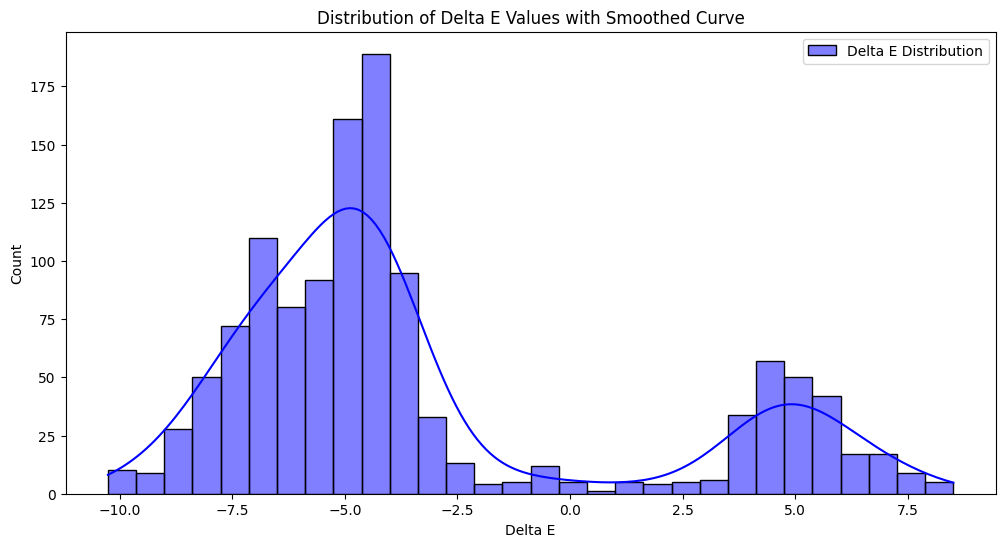

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Plot the histogram and KDE
plt.figure(figsize=(12, 6))
sns.histplot(delta_e_list, kde=True, bins=30, color='blue', stat="count", label="Delta E Distribution")

# Add labels and title
plt.xlabel('Delta E')
plt.ylabel('Count')
plt.title('Distribution of Delta E Values with Smoothed Curve')
plt.legend()
plt.show()


In [ ]:
# Calculate the 2.5th and 97.5th percentiles
bottom_2_5_percentile = np.percentile(delta_e_list, 2.5)
top_2_5_percentile = np.percentile(delta_e_list, 97.5)

# Get the indexes of the bottom and top 2.5% delta E values
bottom_2_5_indexes = [i for i, value in enumerate(delta_e_list) if value <= bottom_2_5_percentile]
top_2_5_indexes = [i for i, value in enumerate(delta_e_list) if value >= top_2_5_percentile]

print(f"Bottom 2.5% Delta E threshold: {bottom_2_5_percentile}")
print(f"Top 2.5% Delta E threshold: {top_2_5_percentile}")
print(f"Indexes of Bottom 2.5% Delta E: {bottom_2_5_indexes}")
print(f"Indexes of Top 2.5% Delta E: {top_2_5_indexes}")
# Get the indexes of 31 sequences whose delta E is closest to 0.0
around_zero_indexes = sorted(range(len(delta_e_list)), key=lambda i: abs(delta_e_list[i]))[:31]

# Get the sequences corresponding to these indexes
around_zero_sequences = [sequence_list[i] for i in around_zero_indexes]

print(f"Indexes of sequences with Delta E around 0.0: {around_zero_indexes}")
# print(f"Sequences with Delta E around 0.0: {around_zero_sequences}")


Bottom 2.5% Delta E threshold: -8.75232962158043
Top 2.5% Delta E threshold: 6.637649492785551
Indexes of Bottom 2.5% Delta E: [10, 168, 243, 290, 291, 328, 332, 348, 373, 391, 423, 424, 443, 487, 494, 495, 587, 607, 630, 666, 720, 728, 737, 775, 783, 789, 793, 816, 827, 829, 889]
Indexes of Top 2.5% Delta E: [0, 91, 306, 315, 335, 363, 371, 388, 389, 404, 408, 448, 452, 457, 467, 483, 530, 573, 588, 593, 601, 624, 731, 762, 804, 819, 835, 837, 839, 885, 906]
Indexes of sequences with Delta E around 0.0: [136, 479, 134, 133, 322, 185, 280, 135, 690, 350, 50, 207, 707, 403, 689, 791, 613, 258, 1170, 860, 222, 355, 426, 522, 464, 717, 535, 422, 640, 571, 250]


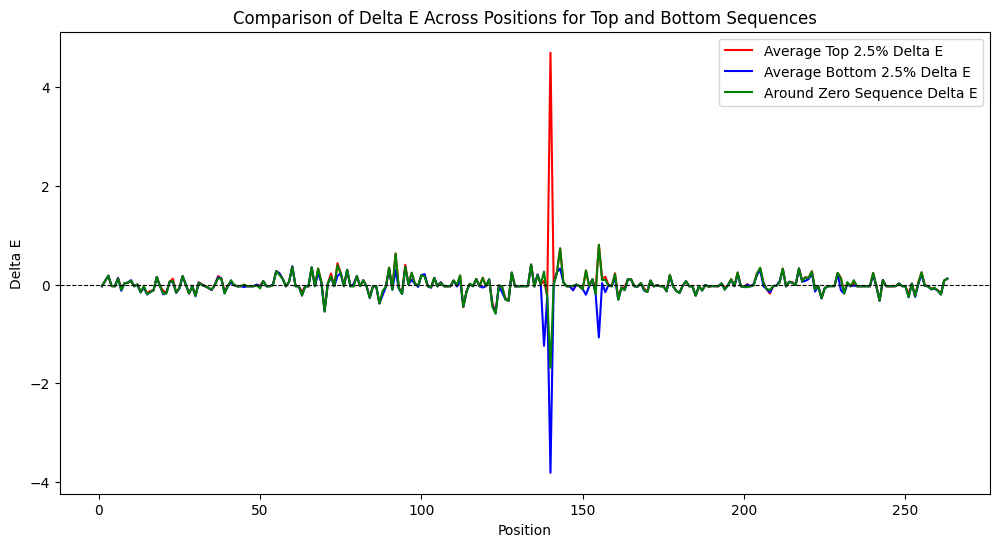

In [ ]:
# Plot the delta E values for the top and bottom sequences
plt.figure(figsize=(12, 6))
# Extract the sequences corresponding to the top and bottom 2.5% indexes
top_2_5_sequences = [sequence_list[i] for i in top_2_5_indexes]
bottom_2_5_sequences = [sequence_list[i] for i in bottom_2_5_indexes]

# Calculate the average delta E for the top 2.5% sequences
average_top_2_5_delta_e = [
    sum(
        J_dict.get((position, pos, old_amino_acid, seq[pos - 1]), 0) -
        J_dict.get((position, pos, new_amino_acid, seq[pos - 1]), 0)
        for seq in top_2_5_sequences
    ) / len(top_2_5_sequences)
    for pos in range(1, 264)
]

# Calculate the average delta E for the bottom 2.5% sequences
average_bottom_2_5_delta_e = [
    sum(
        J_dict.get((position, pos, old_amino_acid, seq[pos - 1]), 0) -
        J_dict.get((position, pos, new_amino_acid, seq[pos - 1]), 0)
        for seq in bottom_2_5_sequences
    ) / len(bottom_2_5_sequences)
    for pos in range(1, 264)
]

# Plot the average delta E for the top 2.5% sequences
plt.plot(range(1, 264), average_top_2_5_delta_e, label='Average Top 2.5% Delta E', color='red')

# Plot the average delta E for the bottom 2.5% sequences
plt.plot(range(1, 264), average_bottom_2_5_delta_e, label='Average Bottom 2.5% Delta E', color='blue')

# Calculate the delta E for the sequences around zero
around_zero_delta_e = []
for pos in range(1, 264):
    delta_e = sum(
        J_dict.get((position, pos, old_amino_acid, seq[pos - 1]), 0) -
        J_dict.get((position, pos, new_amino_acid, seq[pos - 1]), 0)
        for seq in around_zero_sequences
    ) / len(around_zero_sequences)
    around_zero_delta_e.append(delta_e)

# Plot the delta E for the sequences around zero
plt.plot(range(1, 264), around_zero_delta_e, label='Around Zero Sequence Delta E', color='green')

# Add labels, title, and legend
plt.axhline(0, color='black', linestyle='--', linewidth=0.8)  # Add a horizontal line at y=0
plt.xlabel('Position')
plt.ylabel('Delta E')
plt.title('Comparison of Delta E Across Positions for Top and Bottom Sequences')
plt.legend()

# Show the plot
plt.show()

for the to 2.5s as blue color and all others as gray color plot four grpahs(A,B,C,D) matching with the aas with postion on x axis and abundance of the aa on y axis

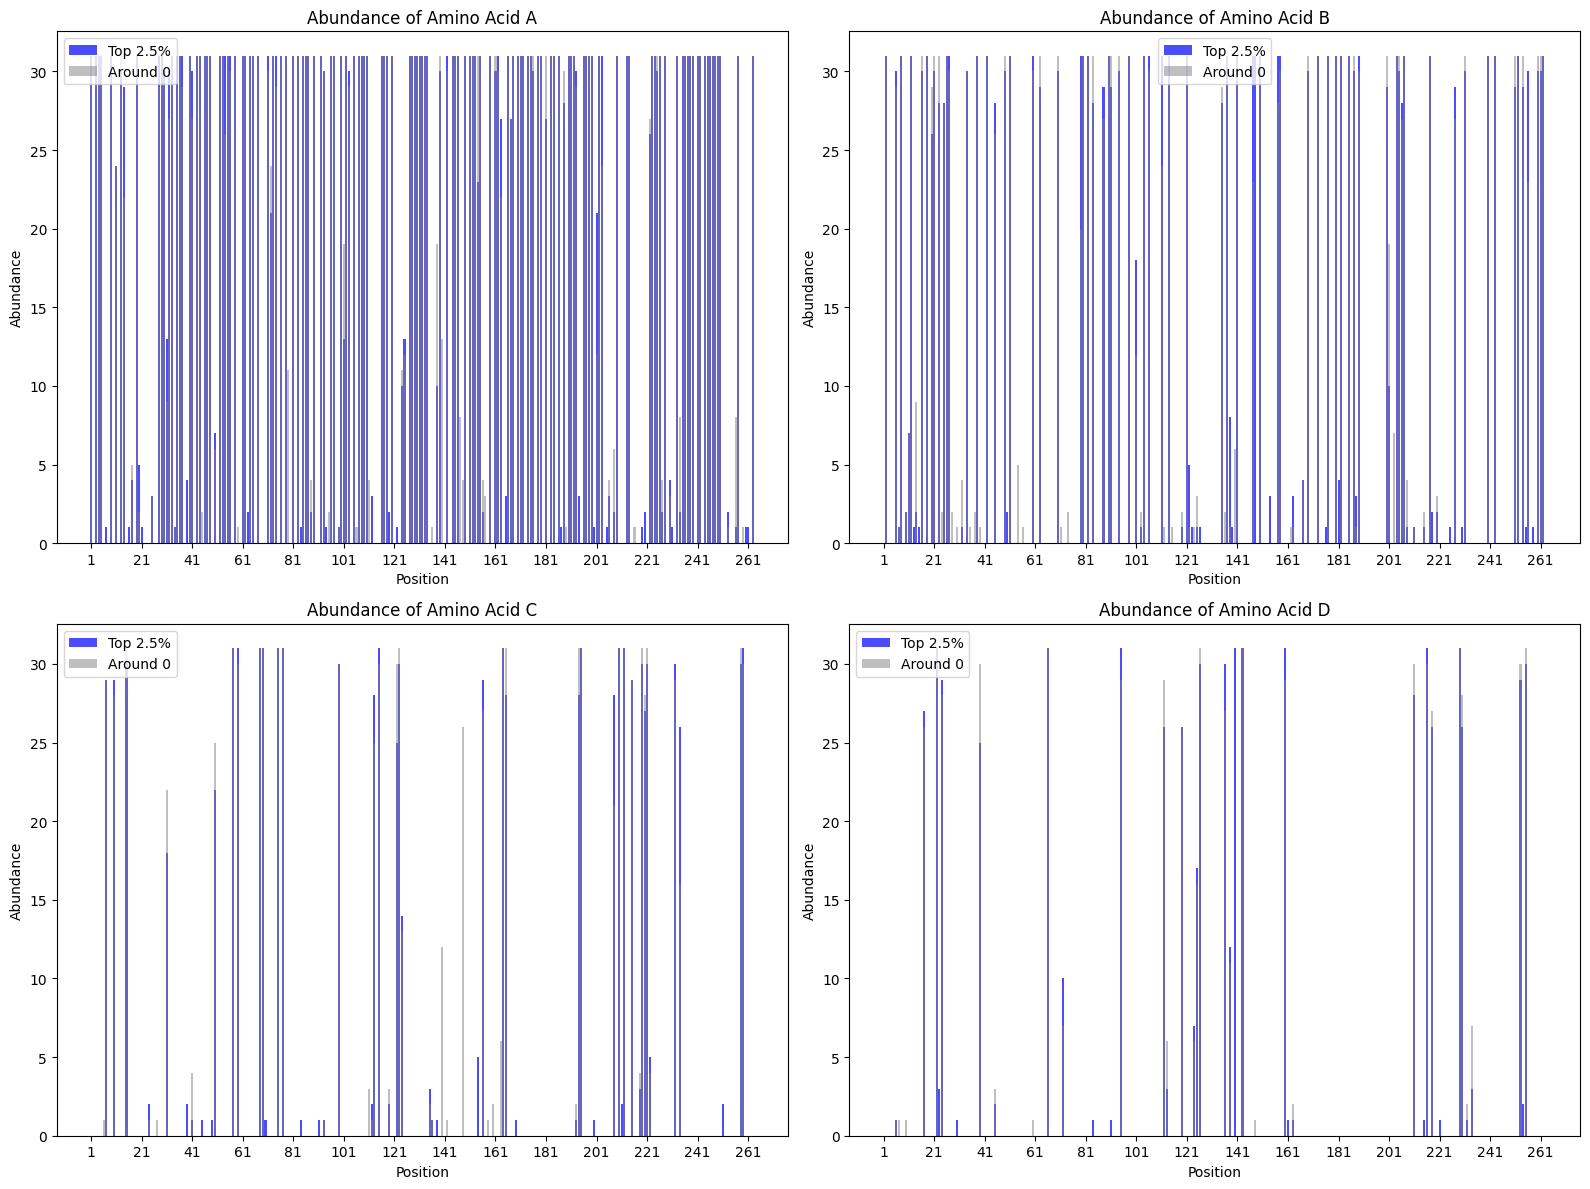

In [ ]:
# Initialize dictionaries to store counts for each amino acid
aa_counts_top_2_5 = {aa: [0] * 263 for aa in amino_acids}
aa_counts_around_zero = {aa: [0] * 263 for aa in amino_acids}

# Count occurrences of each amino acid at each position for the top 2.5% sequences
for seq_index in top_2_5_indexes:
    seq = sequence_list[seq_index]
    for pos in range(263):
        aa_counts_top_2_5[seq[pos]][pos] += 1

# Count occurrences of each amino acid at each position for the sequences around 0
for seq_index in around_zero_indexes:
    seq = sequence_list[seq_index]
    for pos in range(263):
        aa_counts_around_zero[seq[pos]][pos] += 1

# Plot the abundance of each amino acid
plt.figure(figsize=(16, 12))

for i, aa in enumerate(amino_acids):
    plt.subplot(2, 2, i + 1)
    plt.bar(range(1, 264), aa_counts_top_2_5[aa], color='blue', alpha=0.7, label='Top 2.5%')
    plt.bar(range(1, 264), aa_counts_around_zero[aa], color='gray', alpha=0.5, label='Around 0')
    plt.xlabel('Position')
    plt.ylabel('Abundance')
    plt.title(f'Abundance of Amino Acid {aa}')
    plt.xticks(range(1, 264, 20))  # Adjust x-axis ticks for clarity
    plt.legend()

plt.tight_layout()
plt.show()


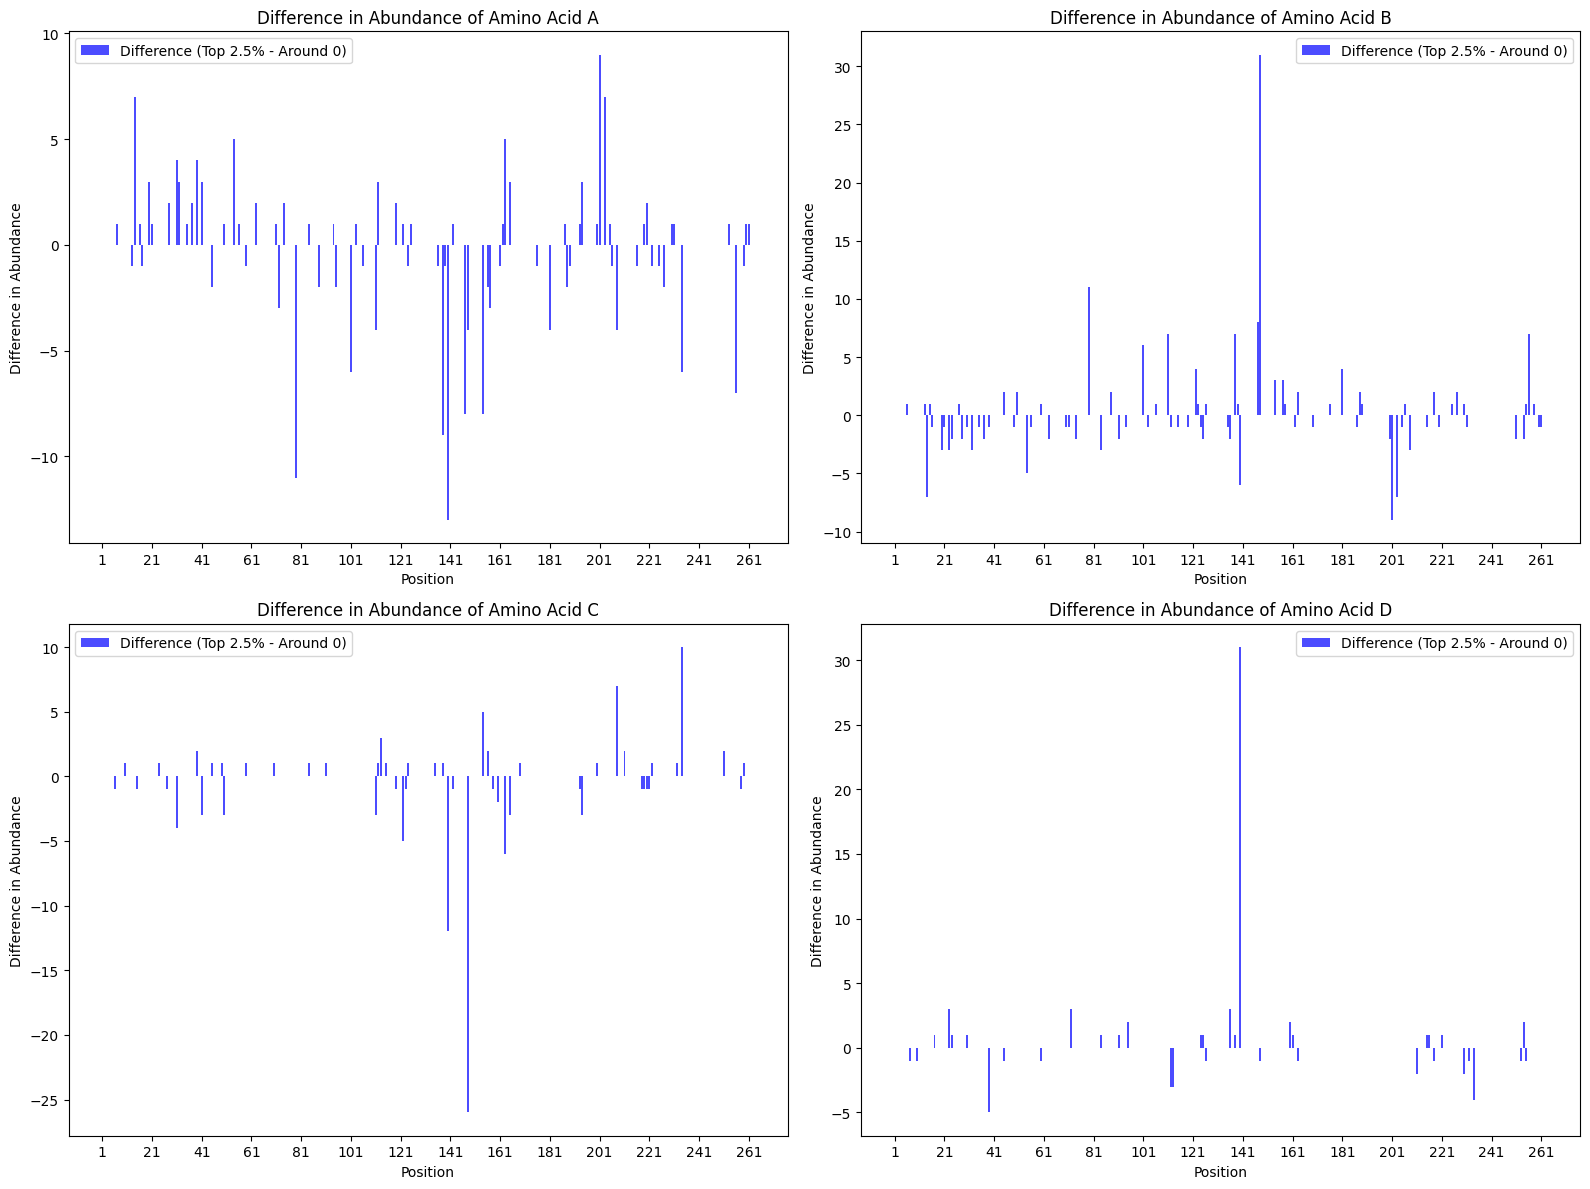

In [ ]:
# Calculate the differences between the counts
aa_counts_difference = {aa: [top - around_zero for top, around_zero in zip(aa_counts_top_2_5[aa], aa_counts_around_zero[aa])] for aa in amino_acids}

# Plot the differences
plt.figure(figsize=(16, 12))

for i, aa in enumerate(amino_acids):
    plt.subplot(2, 2, i + 1)
    plt.bar(range(1, 264), aa_counts_difference[aa], color='blue', alpha=0.7, label='Difference (Top 2.5% - Around 0)')
    plt.xlabel('Position')
    plt.ylabel('Difference in Abundance')
    plt.title(f'Difference in Abundance of Amino Acid {aa}')
    plt.xticks(range(1, 264, 20))  # Adjust x-axis ticks for clarity
    plt.legend()

plt.tight_layout()
plt.show()

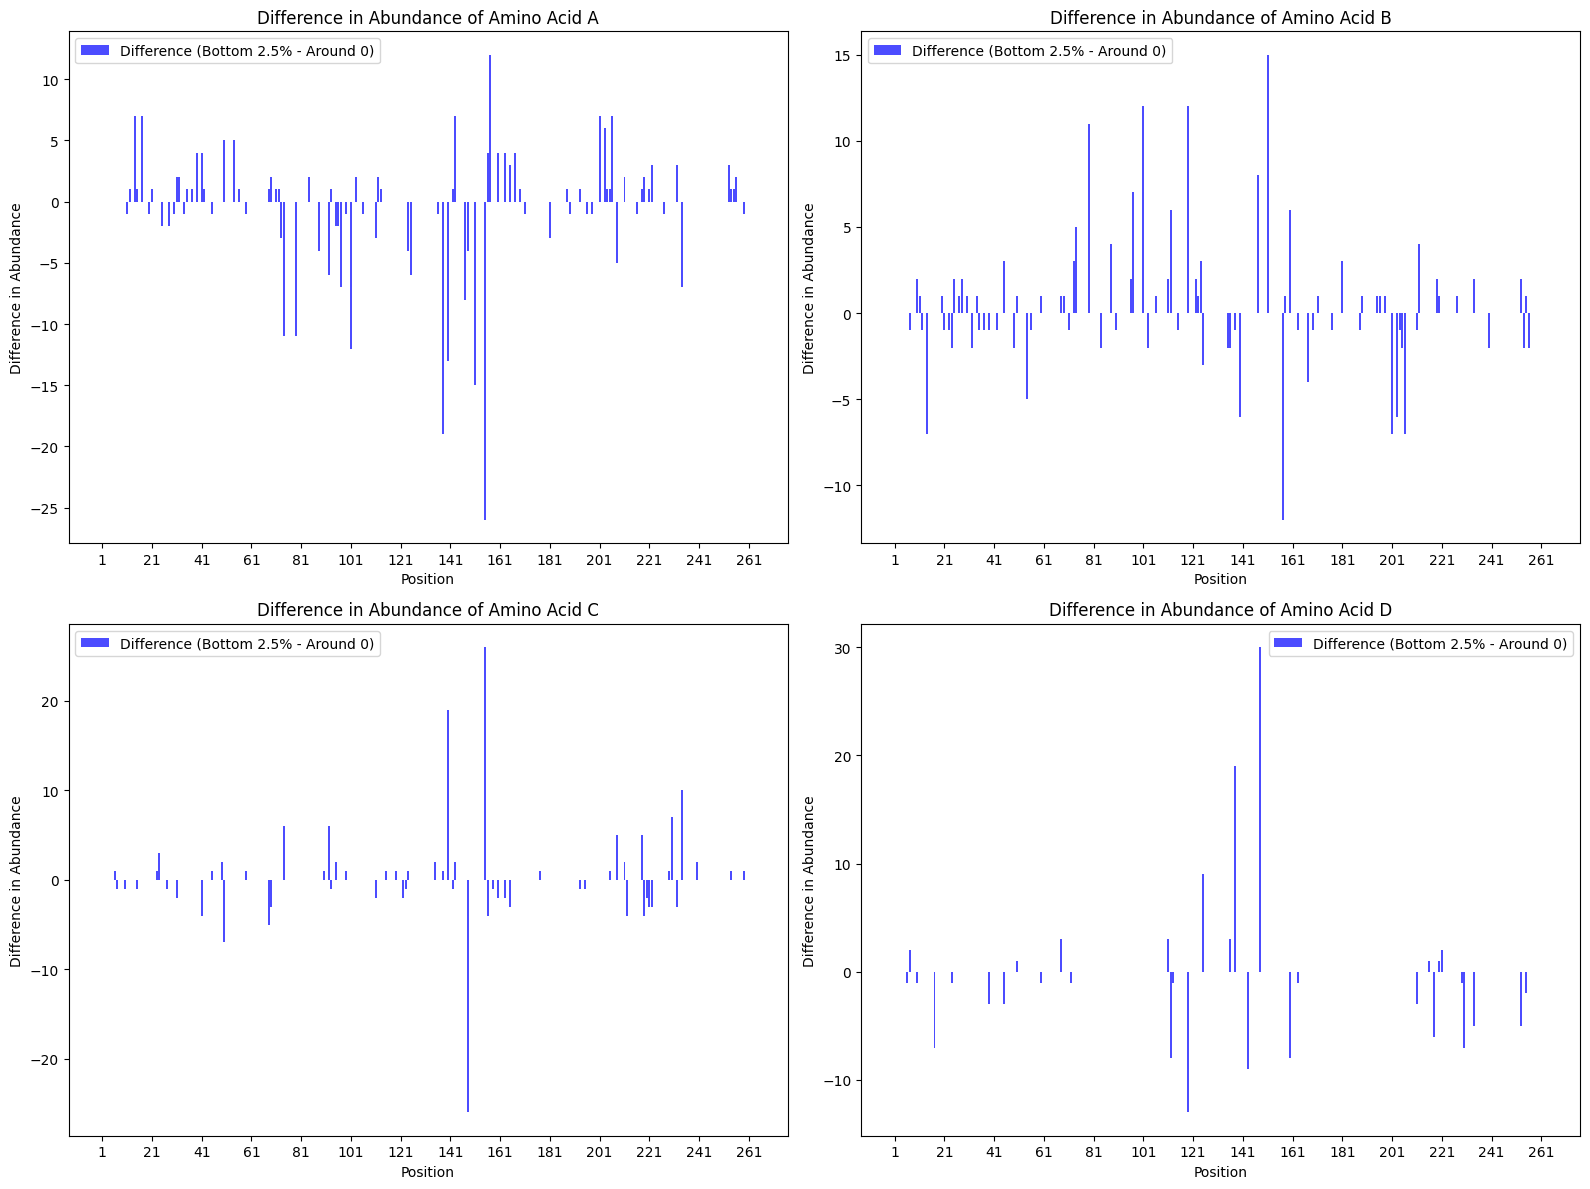

In [ ]:
# Initialize dictionaries to store counts for each amino acid
aa_counts_bottom_2_5 = {aa: [0] * 263 for aa in amino_acids}
aa_counts_around_zero = {aa: [0] * 263 for aa in amino_acids}

# Count occurrences of each amino acid at each position for the bottom 2.5% sequences
for seq_index in bottom_2_5_indexes:
    seq = sequence_list[seq_index]
    for pos in range(263):
        aa_counts_bottom_2_5[seq[pos]][pos] += 1

# Count occurrences of each amino acid at each position for the sequences around 0
for seq_index in around_zero_indexes:
    seq = sequence_list[seq_index]
    for pos in range(263):
        aa_counts_around_zero[seq[pos]][pos] += 1

# Calculate the differences between the counts
aa_counts_difference = {aa: [bottom - around_zero for bottom, around_zero in zip(aa_counts_bottom_2_5[aa], aa_counts_around_zero[aa])] for aa in amino_acids}

# Plot the differences
plt.figure(figsize=(16, 12))

for i, aa in enumerate(amino_acids):
    plt.subplot(2, 2, i + 1)
    plt.bar(range(1, 264), aa_counts_difference[aa], color='blue', alpha=0.7, label='Difference (Bottom 2.5% - Around 0)')
    plt.xlabel('Position')
    plt.ylabel('Difference in Abundance')
    plt.title(f'Difference in Abundance of Amino Acid {aa}')
    plt.xticks(range(1, 264, 20))  # Adjust x-axis ticks for clarity
    plt.legend()

plt.tight_layout()
plt.show()

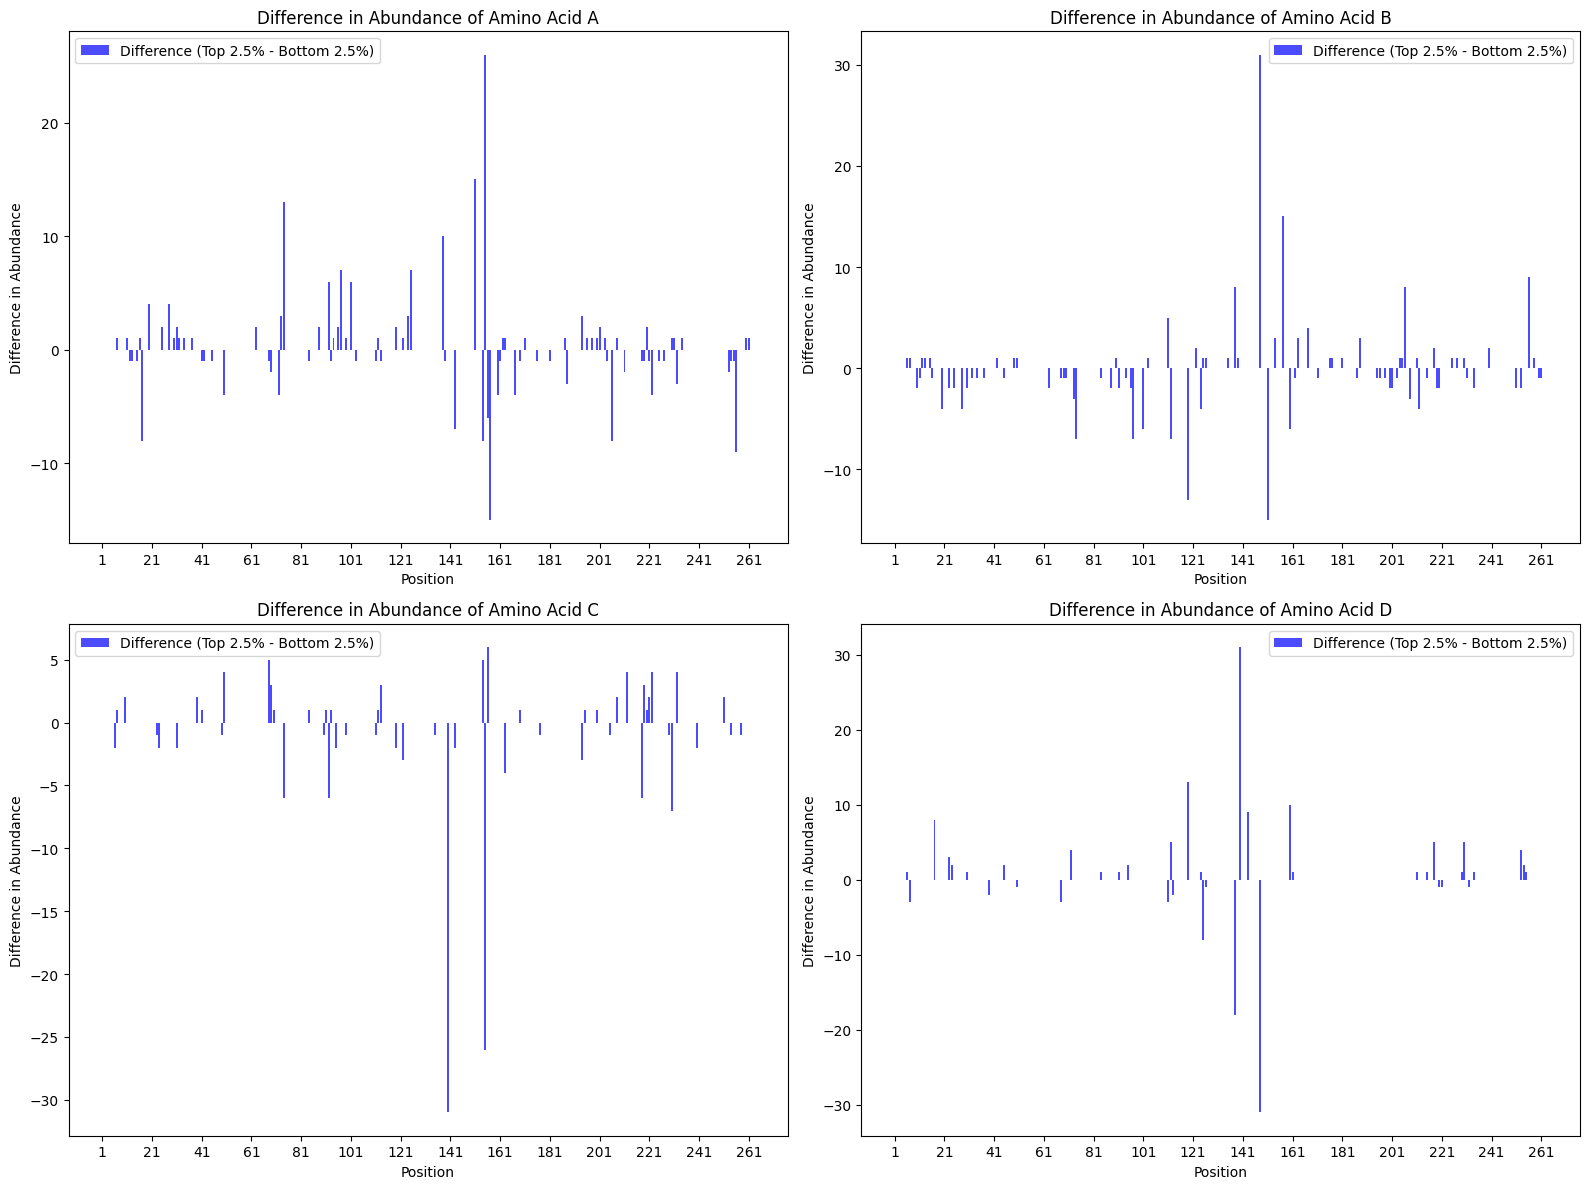

In [ ]:
# Calculate the differences between the counts for top 2.5% and bottom 2.5%
aa_counts_difference_top_bottom = {aa: [top - bottom for top, bottom in zip(aa_counts_top_2_5[aa], aa_counts_bottom_2_5[aa])] for aa in amino_acids}

# Plot the differences
plt.figure(figsize=(16, 12))

for i, aa in enumerate(amino_acids):
    plt.subplot(2, 2, i + 1)
    plt.bar(range(1, 264), aa_counts_difference_top_bottom[aa], color='blue', alpha=0.7, label='Difference (Top 2.5% - Bottom 2.5%)')
    plt.xlabel('Position')
    plt.ylabel('Difference in Abundance')
    plt.title(f'Difference in Abundance of Amino Acid {aa}')
    plt.xticks(range(1, 264, 20))  # Adjust x-axis ticks for clarity
    plt.legend()

plt.tight_layout()
plt.show()

now map the for graphs from top - bottom to one graph: if one position has a positive and a negative value, plot that two lines ont he graph, with four colors of amino acids as ABCD, show all the peaks that has both a negatvie and a positive amino acide, if there is more than one positive and negative, show the strongest positive and negative value

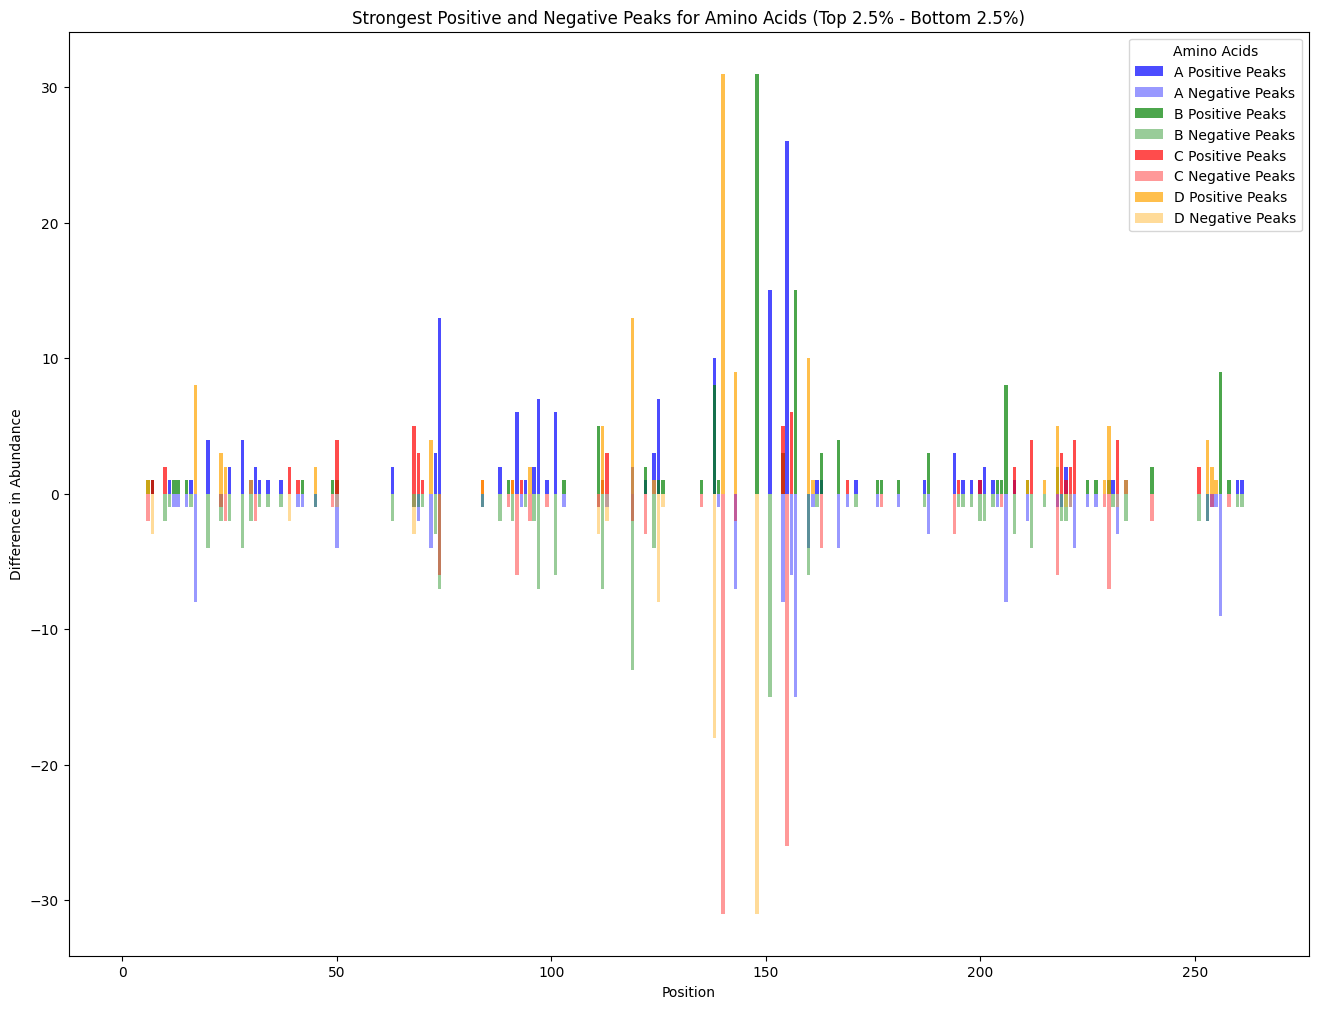

In [ ]:
# Define a distinct color palette for the amino acids
colors_palette = ['blue', 'green', 'red', 'orange']

# Initialize dictionaries to store the strongest positive and negative peaks for each amino acid
strongest_peaks = {aa: {'positive': [0] * 263, 'negative': [0] * 263} for aa in amino_acids}

# Find the strongest positive and negative peaks for each amino acid
for aa in amino_acids:
    for pos in range(263):
        top_value = aa_counts_top_2_5[aa][pos]
        bottom_value = aa_counts_bottom_2_5[aa][pos]
        difference = top_value - bottom_value
        if difference > 0:
            strongest_peaks[aa]['positive'][pos] = difference
        elif difference < 0:
            strongest_peaks[aa]['negative'][pos] = difference

# Plot the results
plt.figure(figsize=(16, 12))

for i, aa in enumerate(amino_acids):
    plt.bar(range(1, 264), strongest_peaks[aa]['positive'], color=colors_palette[i], alpha=0.7, label=f'{aa} Positive Peaks')
    plt.bar(range(1, 264), strongest_peaks[aa]['negative'], color=colors_palette[i], alpha=0.4, label=f'{aa} Negative Peaks')

# Add labels, title, and legend
plt.xlabel('Position')
plt.ylabel('Difference in Abundance')
plt.title('Strongest Positive and Negative Peaks for Amino Acids (Top 2.5% - Bottom 2.5%)')
plt.legend(title="Amino Acids")
plt.show()

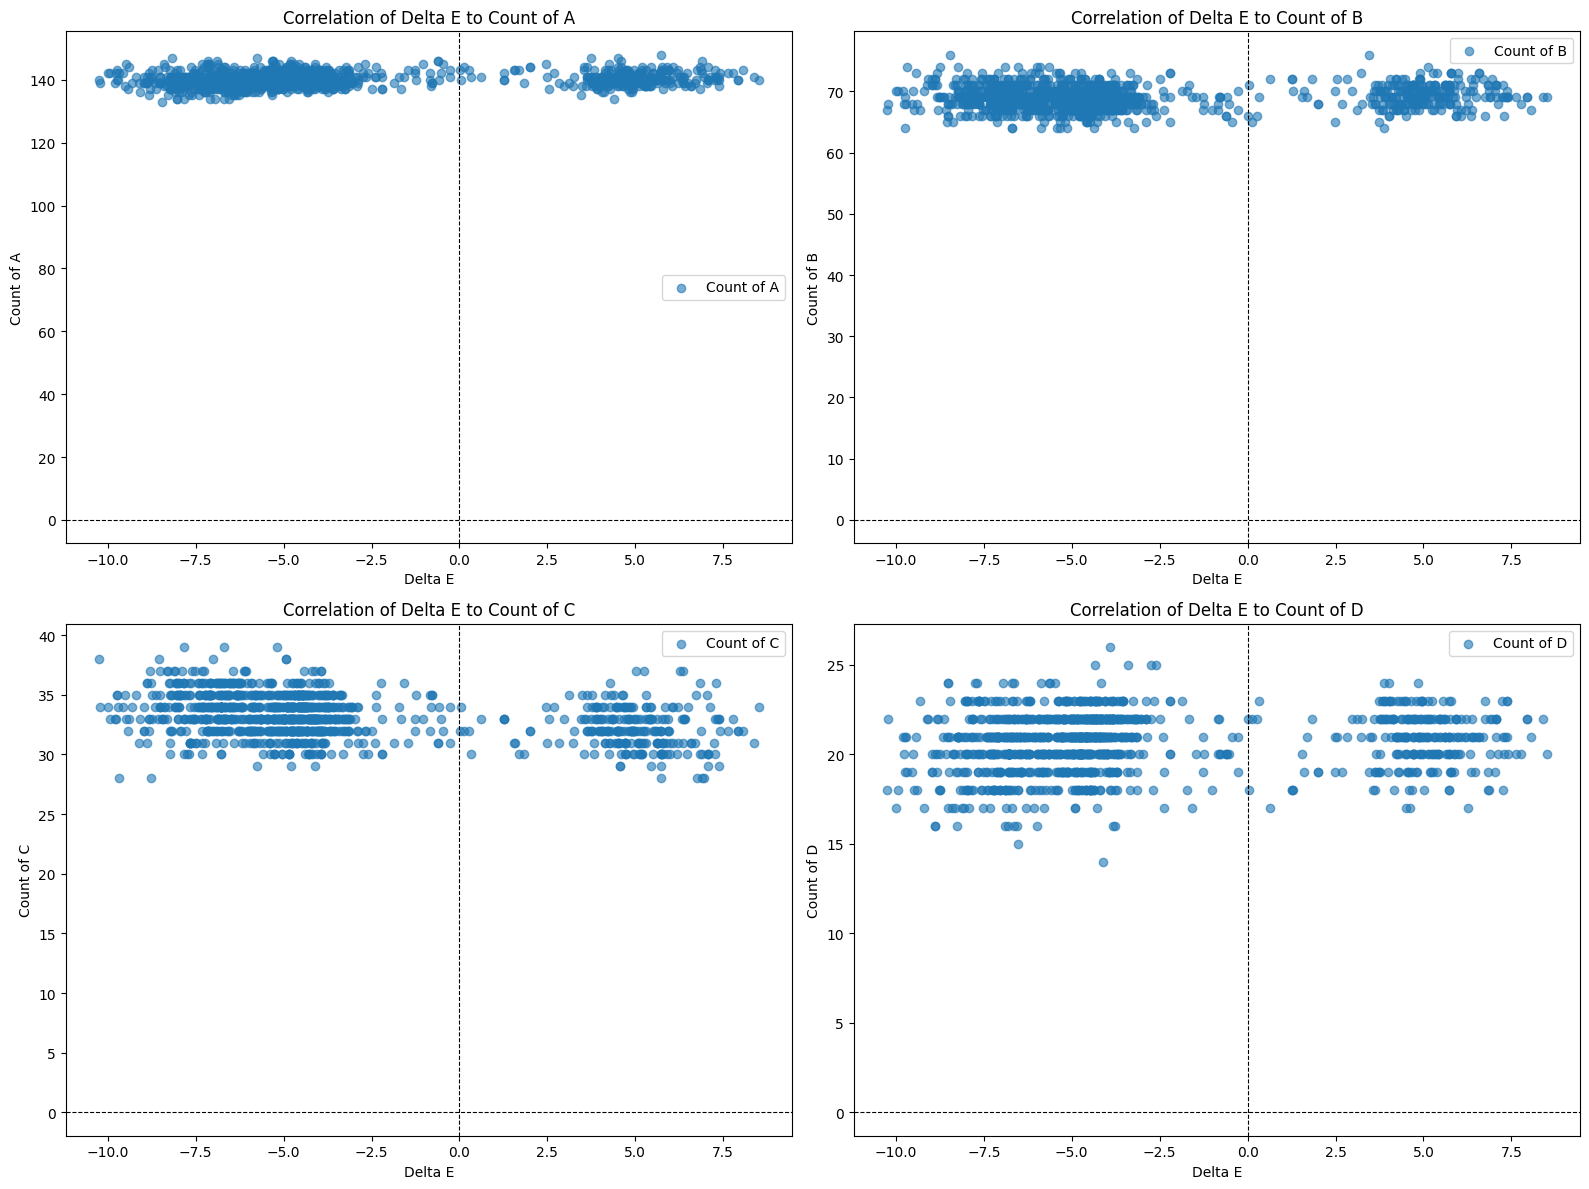

In [ ]:
# Initialize dictionaries to store counts of each amino acid for each sequence
aa_counts_per_sequence = {aa: [] for aa in amino_acids}

# Count occurrences of each amino acid in each sequence
for seq in sequence_list:
    for aa in amino_acids:
        aa_counts_per_sequence[aa].append(seq.count(aa))

# Plot the correlation of delta E to the count of each amino acid
plt.figure(figsize=(16, 12))

for i, aa in enumerate(amino_acids):
    plt.subplot(2, 2, i + 1)
    plt.scatter(delta_e_list, aa_counts_per_sequence[aa], alpha=0.6, label=f'Count of {aa}')
    plt.xlabel('Delta E')
    plt.ylabel(f'Count of {aa}')
    plt.title(f'Correlation of Delta E to Count of {aa}')
    plt.axhline(0, color='black', linestyle='--', linewidth=0.8)  # Add a horizontal line at y=0
    plt.axvline(0, color='black', linestyle='--', linewidth=0.8)  # Add a vertical line at x=0
    plt.legend()

plt.tight_layout()
plt.show()

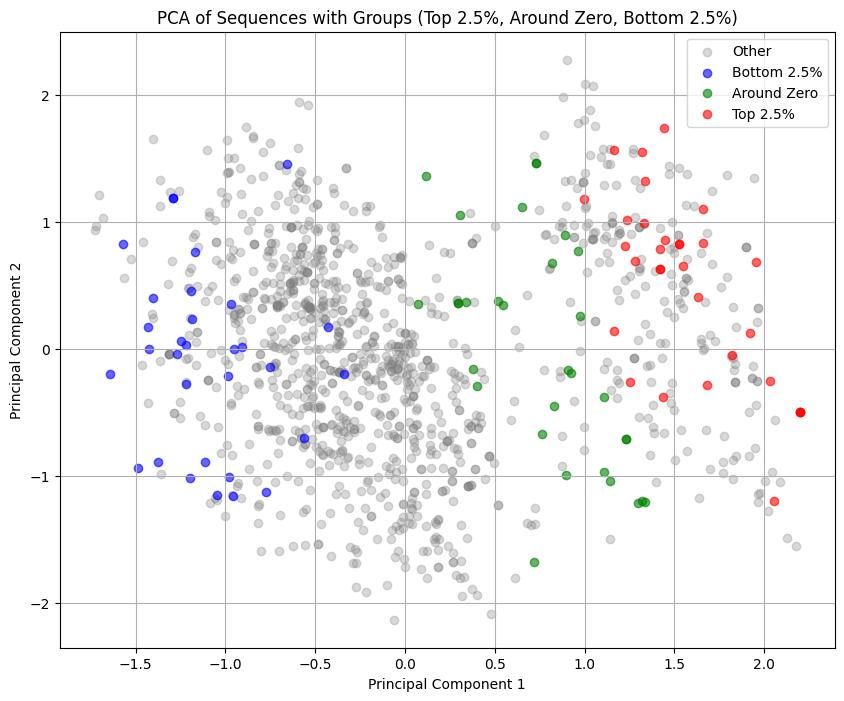

In [ ]:
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# One-hot encode the sequences
amino_acid_to_int = {aa: i for i, aa in enumerate(amino_acids)}
one_hot_encoded_sequences = []
for seq in sequence_list:
    one_hot_seq = np.zeros((len(seq), len(amino_acids)))
    for i, aa in enumerate(seq):
        if aa in amino_acid_to_int:
            one_hot_seq[i, amino_acid_to_int[aa]] = 1
    one_hot_encoded_sequences.append(one_hot_seq.flatten())

X = np.array(one_hot_encoded_sequences)

# Apply PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# Create labels for the three groups (bottom 2.5%, around 0, top 2.5%)
# Initialize with a default label (e.g., -1) for points not in any specific group
labels = np.full(len(sequence_list), -1, dtype=int)
labels[bottom_2_5_indexes] = 0  # Label for bottom 2.5%
labels[around_zero_indexes] = 1 # Label for around 0
labels[top_2_5_indexes] = 2     # Label for top 2.5%

# Define colors and labels for plotting, including a color for the default group
colors = ['blue', 'green', 'red', 'gray'] # Add gray for other points
group_labels = ['Bottom 2.5%', 'Around Zero', 'Top 2.5%', 'Other']

# Plot the PCA results with different colors for each group
plt.figure(figsize=(10, 8))

# Plot the 'Other' points first as background
plt.scatter(X_pca[labels == -1, 0], X_pca[labels == -1, 1], c=colors[3], label=group_labels[3], alpha=0.3)

# Plot the specific groups (bottom, around zero, top)
for i in range(3):
    plt.scatter(X_pca[labels == i, 0], X_pca[labels == i, 1], c=colors[i], label=group_labels[i], alpha=0.6)


plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA of Sequences with Groups (Top 2.5%, Around Zero, Bottom 2.5%)')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Assuming `pca_components` contains the PCA components from the last cell
# and `amino_acids` contains the list of amino acids ['A', 'B', 'C', 'D']

# Combine the absolute values of PCA components for sorting
combined_importance = np.abs(pca.components_[0]) + np.abs(pca.components_[1])

# Get the indices of the most significant features sorted in descending order
sorted_indices = np.argsort(combined_importance)[::-1]

# Iterate over the sorted indices and print the most significant ones
print("Most significant features sorted by combined importance:")
for idx in sorted_indices[:20]:  # Adjust the number to display more or fewer features
    position = (idx // len(amino_acids)) + 1  # 1-based position
    aa = amino_acids[idx % len(amino_acids)]  # Amino acid
    importance = combined_importance[idx]
    print(f"Position {position}, Amino Acid {aa}: {importance}")

Most significant features sorted by combined importance:
Position 148, Amino Acid D: 0.5535633214465958
Position 140, Amino Acid C: 0.5339429203012936
Position 140, Amino Acid D: 0.5088457139292051
Position 148, Amino Acid B: 0.4809335613160317
Position 101, Amino Acid B: 0.45806991132089403
Position 101, Amino Acid A: 0.45806233129868373
Position 124, Amino Acid C: 0.40805133963068907
Position 125, Amino Acid D: 0.3544873269251506
Position 17, Amino Acid D: 0.3533030159989607
Position 17, Amino Acid A: 0.34555084611874104
Position 125, Amino Acid A: 0.32044135120965994
Position 11, Amino Acid A: 0.29453280362462325
Position 11, Amino Acid B: 0.29453280362462325
Position 155, Amino Acid A: 0.278451543044369
Position 155, Amino Acid C: 0.27644390542990593
Position 124, Amino Acid A: 0.25858180284764753
Position 119, Amino Acid D: 0.20747963330588506
Position 31, Amino Acid C: 0.18110299967025287
Position 31, Amino Acid A: 0.17830009601840163
Position 72, Amino Acid D: 0.1701504784098815

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
import numpy as np

# Assuming 'X' (one-hot encoded sequences) is already defined from previous steps
# Assuming 'bottom_2_5_indexes', 'around_zero_indexes', and 'top_2_5_indexes' are defined

# Create labels for the three groups (bottom 2.5%, around 0, top 2.5%)
true_labels = np.zeros(len(sequence_list), dtype=int)
true_labels[bottom_2_5_indexes] = 0  # Label for bottom 2.5%
true_labels[around_zero_indexes] = 1 # Label for around 0
true_labels[top_2_5_indexes] = 2     # Label for top 2.5%


# Apply KMeans clustering
# Use the number of unique true labels as the number of clusters
n_clusters = len(np.unique(true_labels))
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X) # Cluster on the original one-hot encoded data

# Filter for top and bottom labels
top_bottom_indexes = bottom_2_5_indexes + top_2_5_indexes
filtered_true_labels = true_labels[top_bottom_indexes]
filtered_clusters = clusters[top_bottom_indexes]


# Assess cluster quality using ARI and NMI on filtered data
ari_filtered = adjusted_rand_score(filtered_true_labels, filtered_clusters)
nmi_filtered = normalized_mutual_info_score(filtered_true_labels, filtered_clusters)


print(f"Adjusted Rand Index (ARI) for Top and Bottom 2.5%: {ari_filtered}")
print(f"Normalized Mutual Information (NMI) for Top and Bottom 2.5%: {nmi_filtered}")

# You can optionally visualize the clusters if needed, but the request is specifically for ARI and NMI.
# For example, on the PCA reduced data if you still have X_pca:
# plt.figure(figsize=(10, 8))
# scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters, cmap='viridis', alpha=0.6)
# plt.xlabel('Principal Component 1')
# plt.ylabel('Principal Component 2')
# plt.title('PCA of Sequences with KMeans Clustering')
# plt.colorbar(scatter, label='Cluster')
# plt.show()

Adjusted Rand Index (ARI) for Top and Bottom 2.5%: 0.8217491129200585
Normalized Mutual Information (NMI) for Top and Bottom 2.5%: 0.8384638465579372


In [ ]:
# Find the index of the sequence with delta E closest to 0
closest_to_zero_index = min(range(len(delta_e_list)), key=lambda i: abs(delta_e_list[i]))

# Get the sequence corresponding to this index
closest_to_zero_sequence = sequence_list[closest_to_zero_index]

# Print the result
print(f"Index of sequence closest to Delta E of 0: {closest_to_zero_index}")
print(f"Delta E of the closest sequence: {delta_e_list[closest_to_zero_index]}")
print(f"Sequence closest to Delta E of 0: {closest_to_zero_sequence}")

Index of sequence closest to Delta E of 0: 136
Delta E of the closest sequence: 0.01873912345035933
Sequence closest to Delta E of 0: ABAAABCBACABAACBDBABBDBDBBBAAACAABAAABDAABAABAAABCBAABAACACBAABAADACCBADAACACAABABABAAAAABBAABDAABCAAAABABAAAAADDBCAAADABCCAADAAAAAAAABDBAACBADAAAACABAAAAACBBADAACCCAAABAAABAAABAABABAABABABAAAACCAAAABBABBBBBAACDCAACDBDCCCAAAAABADDBCADAAAAABAABAAAAAAABBDBDBACCBBBA


In [ ]:
# Choose the first sequence in the list as the reference sequence
reference_sequence = sequence_list[0]

# Calculate the number of mutations for each sequence
mutations_count = [
    sum(1 for ref, seq in zip(reference_sequence, sequence) if ref != seq)
    for sequence in sequence_list
]

# Print the results
print(f"Number of mutations for each sequence: {mutations_count}")

Number of mutations for each sequence: [0, 21, 18, 16, 17, 20, 16, 16, 15, 17, 22, 18, 17, 20, 21, 20, 20, 20, 13, 13, 13, 14, 20, 20, 20, 21, 20, 14, 14, 14, 18, 15, 14, 15, 14, 14, 12, 22, 20, 20, 22, 18, 17, 18, 19, 19, 18, 19, 21, 21, 23, 13, 21, 15, 21, 20, 15, 20, 18, 17, 18, 15, 17, 12, 16, 17, 16, 22, 18, 19, 18, 23, 15, 14, 19, 15, 14, 21, 13, 20, 20, 18, 17, 16, 13, 12, 13, 13, 13, 19, 19, 18, 18, 16, 16, 16, 15, 15, 16, 16, 19, 18, 12, 12, 16, 15, 16, 19, 17, 13, 14, 16, 18, 12, 15, 15, 14, 14, 17, 17, 16, 16, 16, 16, 16, 18, 15, 15, 19, 18, 20, 21, 21, 21, 22, 23, 23, 15, 14, 15, 15, 11, 14, 12, 13, 13, 13, 12, 13, 12, 16, 14, 21, 18, 18, 20, 15, 15, 15, 14, 15, 15, 15, 17, 13, 15, 16, 15, 23, 20, 13, 14, 15, 15, 14, 14, 19, 12, 13, 17, 20, 22, 17, 14, 17, 12, 12, 13, 19, 19, 14, 14, 16, 18, 14, 12, 21, 18, 18, 18, 16, 15, 16, 15, 20, 12, 15, 23, 13, 14, 17, 19, 18, 11, 14, 15, 15, 16, 12, 14, 14, 24, 19, 23, 17, 17, 17, 15, 15, 15, 16, 22, 22, 17, 17, 16, 16, 16, 20, 20, 1

In [ ]:
from collections import Counter

# Count the occurrences of each mutation count
mutation_counts = Counter(mutations_count)

# Find the most common number of mutations
most_common_mutation = mutation_counts.most_common(1)[0]

print(f"The most common number of mutations is {most_common_mutation[0]} with {most_common_mutation[1]} occurrences.")

The most common number of mutations is 16 with 180 occurrences.


In [ ]:
# Filter sequences with the most common mutation count
most_common_mutation_count = most_common_mutation[0]
most_common_mutation_indexes = [i for i, count in enumerate(mutations_count) if count == most_common_mutation_count]

# Count how many are in the top 2.5% and bottom 2.5%
in_top_2_5 = len(set(most_common_mutation_indexes) & set(top_2_5_indexes))
in_bottom_2_5 = len(set(most_common_mutation_indexes) & set(bottom_2_5_indexes))

print(f"Number of sequences with {most_common_mutation_count} mutations in top 2.5%: {in_top_2_5}")
print(f"Number of sequences with {most_common_mutation_count} mutations in bottom 2.5%: {in_bottom_2_5}")

Number of sequences with 16 mutations in top 2.5%: 5
Number of sequences with 16 mutations in bottom 2.5%: 3


In [ ]:
# Prepare data for storing in a dictionary
top_and_bottom_16_mutations = {
    "top_2_5_sequences": [
        {
            "sequence": sequence_list[i],
            "mutation_positions": [
                pos + 1 for pos, (ref, seq) in enumerate(zip(reference_sequence, sequence_list[i])) if ref != seq
            ]
        }
        for i in set(most_common_mutation_indexes) & set(top_2_5_indexes)
    ],
    "bottom_2_5_sequences": [
        {
            "sequence": sequence_list[i],
            "mutation_positions": [
                pos + 1 for pos, (ref, seq) in enumerate(zip(reference_sequence, sequence_list[i])) if ref != seq
            ]
        }
        for i in set(most_common_mutation_indexes) & set(bottom_2_5_indexes)
    ]
}

# Print the dictionary to verify
print(top_and_bottom_16_mutations)


{'top_2_5_sequences': [{'sequence': 'ABAAABCBACABAACBDBABBDBDABBAADCAABAAABAAABAABAAABCBAAAAACACBAABAADACCBAAAACACABBABABAAABABBAABDAABCAAAABABAAAABDCBCAAADABCCDADAAAAAAAABDBBADBADAAABBABAAAAACBBADAAACCAAABAAABAAABAABABAABABABAAAACCAAAABAAABBABCACDCAACDBDCBCAAAAABADDBCACAAAAABAABAAAAAAACBDBDBACCBBBA', 'mutation_positions': [7, 11, 25, 30, 31, 39, 50, 72, 101, 124, 125, 135, 138, 200, 206, 251]}, {'sequence': 'ABAAABCBACBBAACBDBABBDBDBBBAAAAAABAAABDAABAABAAABCBAAAAACACBAABAADACCBAAAACACABBABABAAABABBAABDAABCAAAABABAAAABDCBCAAABABCBDDDAAAAAAAABDBAADBADAAABBABAAAAAABBADAAACCAAABAAABAAABAABABAABABABAAAACCAAAABBAABBBBCACDCAACDBBCCCAAAAABADDBCADAAAAABAABAAAAAAABBDDDBACCBBBA', 'mutation_positions': [7, 50, 72, 101, 119, 123, 124, 135, 138, 156, 200, 201, 218, 220, 234, 254]}, {'sequence': 'ABAAABCBACABAACBABABADDDBBBAAAAAABAAABDAABAADAAABCBAAAAACACBAABAADACCBAAAACACABBABABAAABABBAABDAABCABAABABAAAABDCBCAAADABCCAABAAAAAAAABDBDADBADAAABBABAAAAACBBADAAACCAAABAAABAABBAABABAABABABAAAACCAAAABBAABBB

In [ ]:
# Find the indexes of sequences with exactly 16 mutations
sequences_with_16_mutations_indexes = [i for i, count in enumerate(mutations_count) if count == 16]

# Prepare data for storing in a dictionary for all sequences with 16 mutations
all_16_mutations_data = [
    {
        "sequence": sequence_list[i],
        "mutation_positions": [
            pos + 1 for pos, (ref, seq) in enumerate(zip(reference_sequence, sequence_list[i])) if ref != seq
        ]
    }
    for i in sequences_with_16_mutations_indexes
]

# Print the dictionary to verify
print(all_16_mutations_data)

[{'sequence': 'ABAAABCBACABAACBABABBDBDBBBBAACAABAAABAAABAABAAABCBAAAAACACBAABAADACCBAAAACACABBABABAAABABBAABDAABCAAAABABAAAABDCBCAAACABBCAADAAAAAAAABDBDADBADAAABBABAAAAACBBADAAACCAAABAAABAAABAABABAABABABAAAACCAAAABBAABBBBCACDCAACDBDCCCAAAAABADDBCACAAAAABAABAAAAAAABBDBDBACCBBBA', 'mutation_positions': [7, 11, 17, 28, 31, 39, 50, 72, 101, 119, 122, 125, 135, 200, 201, 220]}, {'sequence': 'ABAAABCBACBBAACBDBABBDBDBBBAAABBABAAABAAABAABAAABCBAAAAACACBAABAADACCBADAACACABBABABAAABABBCABDAABCABAABABAAAADDCBCAAACABCCCDDAAAAAAAACDBDACBADAAABDABAAAACCBBADAAACCAAABAAABAAABAABABAABABABAAACCCAAAABAAABBBBCACDCAACDBCCCCAAAAABADDBCACAAAAABAABAAAAAAABBDBDBACCBBBA', 'mutation_positions': [7, 31, 32, 39, 50, 92, 111, 119, 124, 140, 148, 155, 193, 200, 218, 220]}, {'sequence': 'ABAAABCBACABAACBDBAABDDDBBBAAACAABAAABDAABAABAAABCBAAAAACACBAABAADACCBADAACACABBABABAAABABBCABDAABCAAAABABAAAABDCBCAAADABCCADDAAAAAAAABDBDACBADAAABDABAAAAACBBADAAACCAAABAAABAAABAABABAABABABAAAACCAAAABBAAABABCACDCAACDBDCCCAAAAABADDB

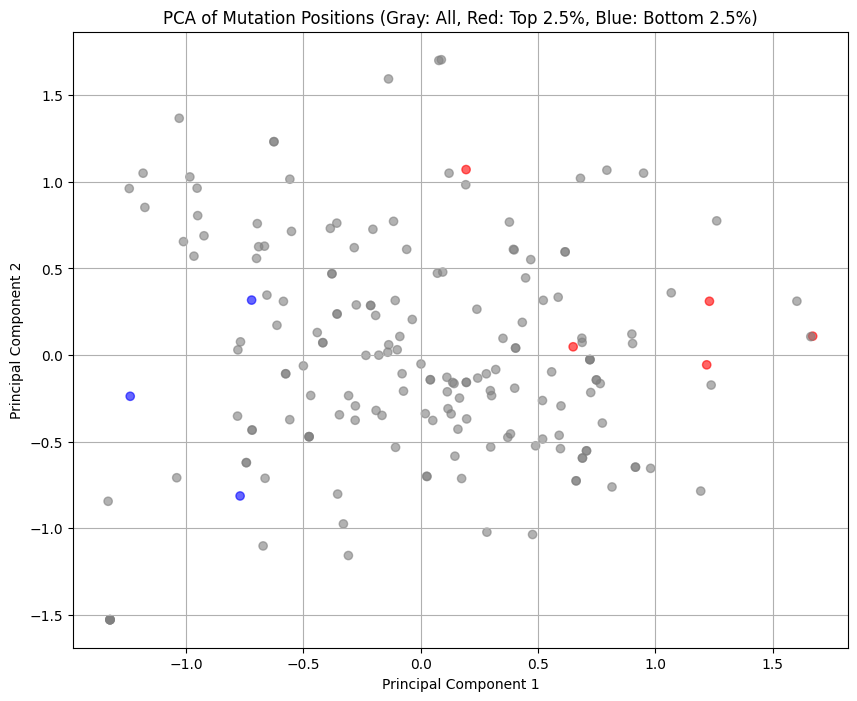

In [ ]:
from sklearn.decomposition import PCA

import matplotlib.pyplot as plt

# Create mutation vectors for all sequences
mutation_vectors = np.zeros((len(sequence_list), len(reference_sequence)), dtype=int)
for i, sequence in enumerate(sequence_list):
    for j, (ref, seq) in enumerate(zip(reference_sequence, sequence)):
        if ref != seq:
            mutation_vectors[i, j] = 1

# Filter mutation vectors for sequences with 16 mutations
valid_indexes = [index for index in sequences_with_16_mutations_indexes if index < len(mutation_vectors)]
mutation_vectors_16 = mutation_vectors[valid_indexes]

# Apply PCA to reduce dimensions to 2
pca = PCA(n_components=2)
mutation_vectors_pca = pca.fit_transform(mutation_vectors_16)

# Prepare colors for the plot
colors = ['gray'] * len(sequences_with_16_mutations_indexes)
for i, index in enumerate(sequences_with_16_mutations_indexes):
    if index in top_2_5_indexes:
        colors[i] = 'red'
    elif index in bottom_2_5_indexes:
        colors[i] = 'blue'

# Plot the PCA results
plt.figure(figsize=(10, 8))
plt.scatter(mutation_vectors_pca[:, 0], mutation_vectors_pca[:, 1], c=colors, alpha=0.6)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA of Mutation Positions (Gray: All, Red: Top 2.5%, Blue: Bottom 2.5%)')
plt.grid(True)
plt.show()

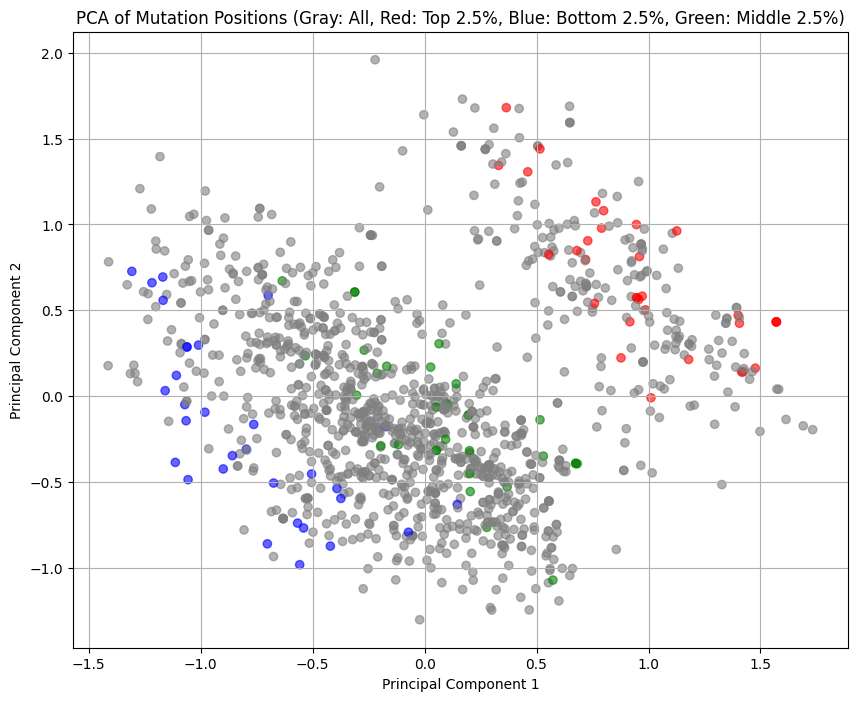

In [ ]:
from sklearn.decomposition import PCA
import numpy as np

import matplotlib.pyplot as plt

# Create mutation vectors for all sequences
mutation_vectors = np.zeros((len(sequence_list), len(reference_sequence)), dtype=int)
for i, sequence in enumerate(sequence_list):
    for j, (ref, seq) in enumerate(zip(reference_sequence, sequence)):
        if ref != seq:
            mutation_vectors[i, j] = 1

# Apply PCA to reduce dimensions to 2
pca = PCA(n_components=2)
mutation_vectors_pca = pca.fit_transform(mutation_vectors)

# Prepare colors for the plot
colors = ['gray'] * len(sequence_list)
for i, index in enumerate(range(len(sequence_list))):
    if index in top_2_5_indexes:
        colors[i] = 'red'
    elif index in bottom_2_5_indexes:
        colors[i] = 'blue'
    elif index in around_zero_indexes:
        colors[i] = 'green'

# Plot the PCA results
plt.figure(figsize=(10, 8))
plt.scatter(mutation_vectors_pca[:, 0], mutation_vectors_pca[:, 1], c=colors, alpha=0.6)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA of Mutation Positions (Gray: All, Red: Top 2.5%, Blue: Bottom 2.5%, Green: Middle 2.5%)')
plt.grid(True)
plt.show()


In [ ]:
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

# Filter the data for the three labels (top, bottom, middle)
three_labels_indexes = top_2_5_indexes + bottom_2_5_indexes + around_zero_indexes
filtered_X_three = X[three_labels_indexes]
filtered_true_labels_three = true_labels[three_labels_indexes]

# Perform KMeans clustering on the filtered data
kmeans_three = KMeans(n_clusters=3, random_state=42, n_init=10)
filtered_clusters_three = kmeans_three.fit_predict(filtered_X_three)

# Calculate NMI and ARI for the three labels
nmi_three = normalized_mutual_info_score(filtered_true_labels_three, filtered_clusters_three)
ari_three = adjusted_rand_score(filtered_true_labels_three, filtered_clusters_three)

# Print the results
print(f"Normalized Mutual Information (NMI) for three labels: {nmi_three}")
print(f"Adjusted Rand Index (ARI) for three labels: {ari_three}")

Normalized Mutual Information (NMI) for three labels: 0.9267402220106861
Adjusted Rand Index (ARI) for three labels: 0.9362247845275782


Top 10 important positions and their combined importance:
Position 140: 0.8301561948050356
Position 148: 0.8082993394276303
Position 119: 0.7194606171887583
Position 101: 0.6041211626380739
Position 11: 0.4990716581939178
Position 155: 0.47712575230506116
Position 17: 0.3982012066751348
Position 122: 0.39043407625355764
Position 31: 0.3577325206588484
Position 124: 0.3244091505907952


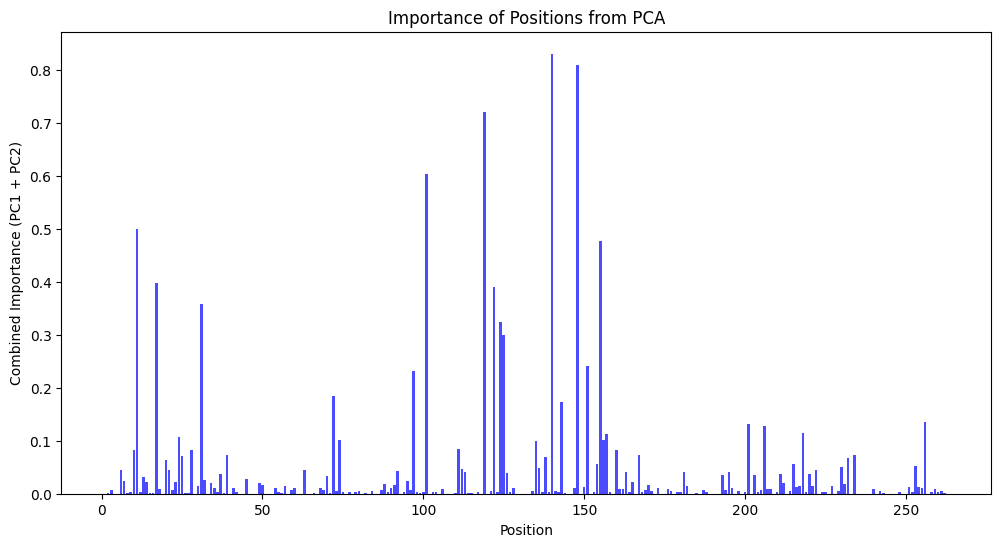

In [ ]:
# Get the PCA components (loadings)
pca_components = pca.components_

# Calculate the absolute contribution of each position to the first principal component
position_importance_pc1 = np.abs(pca_components[0])

# Calculate the absolute contribution of each position to the second principal component
position_importance_pc2 = np.abs(pca_components[1])

# Combine the contributions for both components
combined_importance = position_importance_pc1 + position_importance_pc2

# Get the positions sorted by their importance
sorted_positions = np.argsort(combined_importance)[::-1]  # Sort in descending order

# Print the top 10 most important positions
top_positions = sorted_positions[:10]
print("Top 10 important positions and their combined importance:")
for pos in top_positions:
    print(f"Position {pos + 1}: {combined_importance[pos]}")

# Plot the importance of positions
plt.figure(figsize=(12, 6))
plt.bar(range(1, len(combined_importance) + 1), combined_importance, color='blue', alpha=0.7)
plt.xlabel('Position')
plt.ylabel('Combined Importance (PC1 + PC2)')
plt.title('Importance of Positions from PCA')
plt.show()

# double mutation

In [ ]:
def double_mutation_delta_delta_E(seq, pos1, aa1_new, pos2, aa2_new, J_dict, old_amino_acid1, old_amino_acid2):
    """
    Calculate delta delta E for a double mutation:
    delta_delta_E = delta_E_double - (delta_E_single1 + delta_E_single2)
    seq: original sequence (string)
    pos1, pos2: 1-based positions to mutate
    aa1_new, aa2_new: new amino acids at pos1 and pos2
    J_dict: dictionary of J matrix
    old_amino_acid1, old_amino_acid2: original amino acids at pos1 and pos2
    """
    # Single mutation at pos1
    delta_E_single1 = 0
    for other_pos in range(1, len(seq) + 1):
        if other_pos == pos1:
            continue
        other_aa = seq[other_pos - 1]
        delta_E_single1 += J_dict.get((pos1, other_pos, old_amino_acid1, other_aa), 0) - J_dict.get((pos1, other_pos, aa1_new, other_aa), 0)

    # Single mutation at pos2
    delta_E_single2 = 0
    for other_pos in range(1, len(seq) + 1):
        if other_pos == pos2:
            continue
        other_aa = seq[other_pos - 1]
        delta_E_single2 += J_dict.get((pos2, other_pos, old_amino_acid2, other_aa), 0) - J_dict.get((pos2, other_pos, aa2_new, other_aa), 0)

    # Double mutation
    seq_double = list(seq)
    seq_double[pos1 - 1] = aa1_new
    seq_double[pos2 - 1] = aa2_new

    delta_E_double = 0
    # Contribution for pos1
    for other_pos in range(1, len(seq) + 1):
        if other_pos == pos1:
            continue
        other_aa = seq_double[other_pos - 1]
        delta_E_double += J_dict.get((pos1, other_pos, aa1_new, other_aa), 0) - J_dict.get((pos1, other_pos, old_amino_acid1, seq[other_pos - 1]), 0)
    # Contribution for pos2
    for other_pos in range(1, len(seq) + 1):
        if other_pos == pos2:
            continue
        other_aa = seq_double[other_pos - 1]
        delta_E_double += J_dict.get((pos2, other_pos, aa2_new, other_aa), 0) - J_dict.get((pos2, other_pos, old_amino_acid2, seq[other_pos - 1]), 0)

    # Remove double-counted interaction between pos1 and pos2
    # (since both loops above include it twice)
    # aa1_old = seq[pos1 - 1]
    # aa2_old = seq[pos2 - 1]
    double_old = J_dict.get((pos1, pos2, old_amino_acid1, old_amino_acid2), 0)
    double_new = J_dict.get((pos1, pos2, aa1_new, aa2_new), 0)
    delta_E_double -= double_new - double_old

    delta_delta_E = delta_E_double - (delta_E_single1 + delta_E_single2)
    # print(delta_delta_E, delta_E_double,delta_E_single1, delta_E_single2)
    return delta_delta_E

delta delta E for C140D and B148D (on sequence 0): 0.04471814911812544


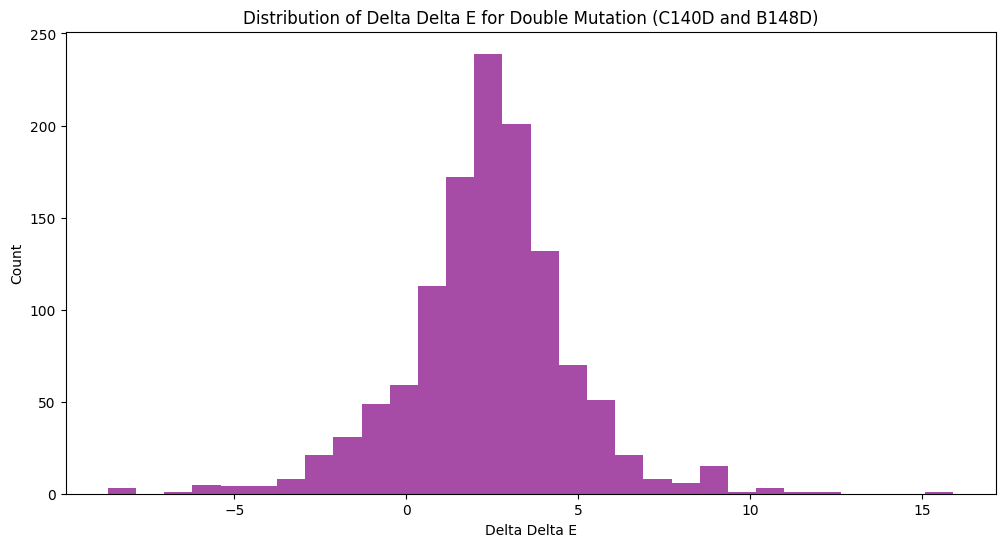

In [ ]:
# Calculate delta delta E for double mutation: C140D and B148D on the first sequence

seq = sequence_list[0]
# Positions are 1-based
pos1, old_amino_acid1, aa1_new = 140, 'D' ,'C' # C140D
pos2, old_amino_acid2, aa2_new = 148, 'D', 'B'  # D148B

# old_amino_acid1 = seq[pos1 - 1]  # original at 140
# old_amino_acid2 = seq[pos2 - 1]  # original at 148

delta_delta_e = double_mutation_delta_delta_E(
    seq, pos1, aa1_new, pos2, aa2_new, J_dict, old_amino_acid1, old_amino_acid2
)

print(f"delta delta E for C140D and B148D (on sequence 0): {delta_delta_e}")

# Calculate delta delta E for all sequences
delta_delta_e_list = []
for seq in sequence_list:
    delta_delta_e = double_mutation_delta_delta_E(
        seq, pos1, aa1_new, pos2, aa2_new, J_dict, old_amino_acid1, old_amino_acid2
    )
    delta_delta_e_list.append(delta_delta_e)

# Plot the distribution
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))
plt.hist(delta_delta_e_list, bins=30, color='purple', alpha=0.7)
plt.xlabel('Delta Delta E')
plt.ylabel('Count')
plt.title('Distribution of Delta Delta E for Double Mutation (C140D and B148D)')
plt.show()

In [ ]:
# Read the sequence from the file
with open('in.consensus.reduce4.seq', 'r') as f:
    consensus_sequence = f.read().strip()

# Define the positions and mutations
pos1, old_amino_acid1, aa1_new = 140, 'C', 'D'  # A1B
pos2, old_amino_acid2, aa2_new = 148, 'D', 'B'  # B2A

# Calculate delta delta E for the double mutation
delta_delta_e_consensus = double_mutation_delta_delta_E(
    consensus_sequence, pos1, aa1_new, pos2, aa2_new, J_dict, old_amino_acid1, old_amino_acid2
)

print(f"Delta Delta E for A1B and B2A (on consensus sequence): {delta_delta_e_consensus}")

Delta Delta E for A1B and B2A (on consensus sequence): 12.05556587036699


Recalculated Delta E for C140D: [5.055151157081127, -3.3114665895700455, 2.113368347287178, 3.10034860111773, -7.65487221442163, -8.8195726480335, -9.428811136633158, -7.312339974567294, -5.459149539470673, -8.777774618938565, -9.726325817406178, -6.813780514523387, 4.319446744397283, -1.1912255436182022, 0.32155172526836395, -6.395422860980034, -6.395422860980034, -6.395422860980034, -4.921093313023448, -4.921093313023448, 0.5420557428151369, -4.992795143276453, -6.390942497178912, -5.864117691293359, -5.864117691293359, -7.862620422616601, -7.874507853761315, -5.19665284268558, 0.0075444746762514114, 0.12073466368019581, -5.63054065220058, -5.7796316128224134, 2.1576169300824404, 3.4612293262034655, -6.128479389473796, -6.128479389473796, 2.380311818793416, -6.483519544824958, -5.733950329944491, -8.09222793392837, -8.26756221242249, -5.892742989584804, -6.2433803062886, -5.892742989584804, -6.037728412076831, -6.037728412076831, -5.067943384870887, -4.836782982572913, -6.04248204641

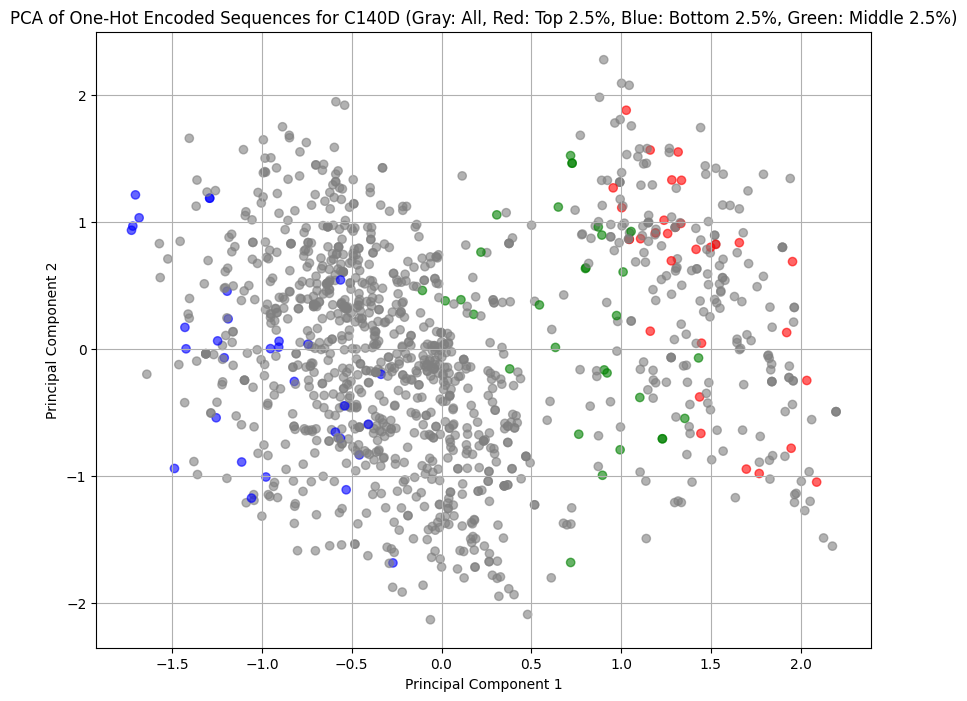

In [ ]:
# Recalculate delta E for single mutation C140D
delta_e_c140d = []
for seq in sequence_list:
    delta_e = 0
    for other_pos in range(1, 264):
        if other_pos == 140:
            continue
        other_aa = seq[other_pos - 1]
        delta_e += J_dict.get((140, other_pos, 'C', other_aa), 0) - J_dict.get((140, other_pos, 'D', other_aa), 0)
    delta_e_c140d.append(delta_e)

# Print the recalculated delta E values for verification
print(f"Recalculated Delta E for C140D: {delta_e_c140d}")

# One-hot encode the sequences for C140D
one_hot_encoded_c140d = []
for seq in sequence_list:
    one_hot_seq = np.zeros((len(seq), len(amino_acids)))
    for i, aa in enumerate(seq):
        if aa in amino_acid_to_int:
            one_hot_seq[i, amino_acid_to_int[aa]] = 1
    one_hot_encoded_c140d.append(one_hot_seq.flatten())

X_c140d = np.array(one_hot_encoded_c140d)

# Apply PCA to reduce dimensions to 2
pca_c140d = PCA(n_components=2)
X_pca_c140d = pca_c140d.fit_transform(X_c140d)
# Recalculate the top, middle, and bottom 2.5% indexes based on new delta E for C140D
top_2_5_percentile_c140d = np.percentile(delta_e_c140d, 97.5)
bottom_2_5_percentile_c140d = np.percentile(delta_e_c140d, 2.5)

top_2_5_indexes_c140d = [i for i, value in enumerate(delta_e_c140d) if value >= top_2_5_percentile_c140d]
bottom_2_5_indexes_c140d = [i for i, value in enumerate(delta_e_c140d) if value <= bottom_2_5_percentile_c140d]
middle_indexes_c140d = sorted(range(len(delta_e_c140d)), key=lambda i: abs(delta_e_c140d[i]))[:31]

# Prepare colors for the plot based on recalculated indexes
colors_c140d = ['gray'] * len(sequence_list)
for i, index in enumerate(range(len(sequence_list))):
    if index in top_2_5_indexes_c140d:
        colors_c140d[i] = 'red'
    elif index in bottom_2_5_indexes_c140d:
        colors_c140d[i] = 'blue'
    elif index in middle_indexes_c140d:
        colors_c140d[i] = 'green'

# Plot the PCA results for C140D
plt.figure(figsize=(10, 8))
plt.scatter(X_pca_c140d[:, 0], X_pca_c140d[:, 1], c=colors_c140d, alpha=0.6)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA of One-Hot Encoded Sequences for C140D (Gray: All, Red: Top 2.5%, Blue: Bottom 2.5%, Green: Middle 2.5%)')
plt.grid(True)
plt.show()


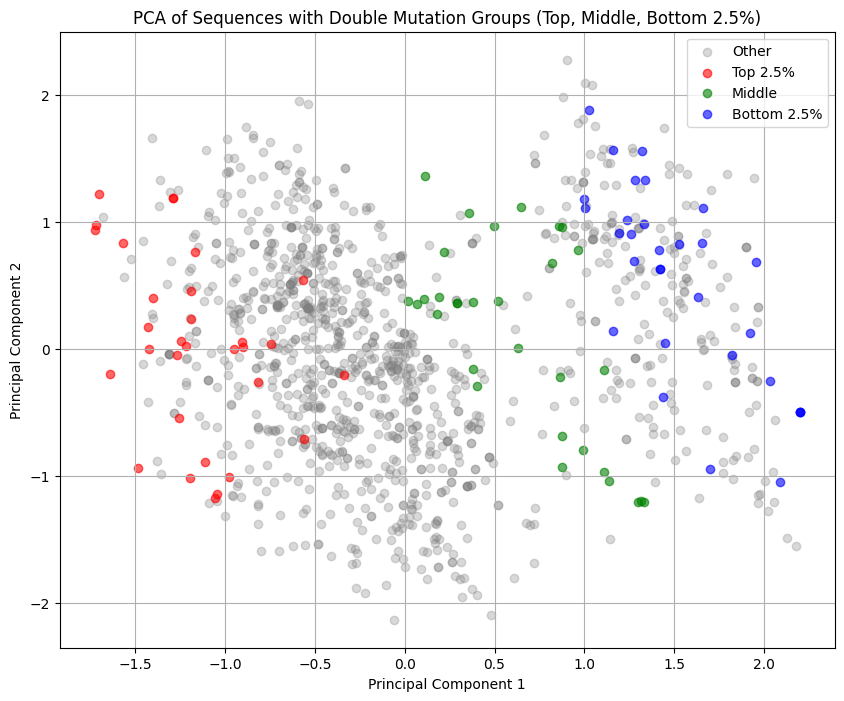

In [ ]:
from sklearn.decomposition import PCA
import numpy as np

import matplotlib.pyplot as plt

# Calculate delta delta E for all sequences
delta_delta_e_list = []
for seq in sequence_list:
    delta_delta_e = double_mutation_delta_delta_E(
        seq, pos1, aa1_new, pos2, aa2_new, J_dict, old_amino_acid1, old_amino_acid2
    )
    delta_delta_e_list.append(delta_delta_e)

# Identify the top, middle, and bottom 2.5% indexes
top_2_5_percentile = np.percentile(delta_delta_e_list, 97.5)
bottom_2_5_percentile = np.percentile(delta_delta_e_list, 2.5)

top_2_5_indexes = [i for i, value in enumerate(delta_delta_e_list) if value >= top_2_5_percentile]
bottom_2_5_indexes = [i for i, value in enumerate(delta_delta_e_list) if value <= bottom_2_5_percentile]
middle_indexes = sorted(range(len(delta_delta_e_list)), key=lambda i: abs(delta_delta_e_list[i]))[:31]

# One-hot encode the sequences
one_hot_encoded_sequences = []
for seq in sequence_list:
    one_hot_seq = np.zeros((len(seq), len(amino_acids)))
    for i, aa in enumerate(seq):
        if aa in amino_acid_to_int:
            one_hot_seq[i, amino_acid_to_int[aa]] = 1
    one_hot_encoded_sequences.append(one_hot_seq.flatten())

X = np.array(one_hot_encoded_sequences)

# Apply PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# Create labels for the three groups
labels = np.full(len(sequence_list), -1, dtype=int)  # Default label for other sequences
labels[top_2_5_indexes] = 0  # Label for top 2.5%
labels[middle_indexes] = 1   # Label for middle
labels[bottom_2_5_indexes] = 2  # Label for bottom 2.5%

# Define colors and labels for plotting
colors = ['red', 'green', 'blue', 'gray']  # Gray for other sequences
group_labels = ['Top 2.5%', 'Middle', 'Bottom 2.5%', 'Other']

# Plot the PCA results
plt.figure(figsize=(10, 8))

# Plot the 'Other' points first as background
plt.scatter(X_pca[labels == -1, 0], X_pca[labels == -1, 1], c=colors[3], label=group_labels[3], alpha=0.3)

# Plot the specific groups
for i in range(3):
    plt.scatter(X_pca[labels == i, 0], X_pca[labels == i, 1], c=colors[i], label=group_labels[i], alpha=0.6)

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA of Sequences with Double Mutation Groups (Top, Middle, Bottom 2.5%)')
plt.legend()
plt.grid(True)
plt.show()
# Encode sequences using frequency of amino acids at each position
frequency_encoded_sequences = []
for seq in sequence_list:
    freq_encoding = []
    for aa in amino_acids:
        freq_encoding.extend([seq[:pos].count(aa) / (pos + 1) for pos in range(len(seq))])

draw side by side the distribution plot of single mutation C140D, single mut D148B, and double mutation of C140D D148B

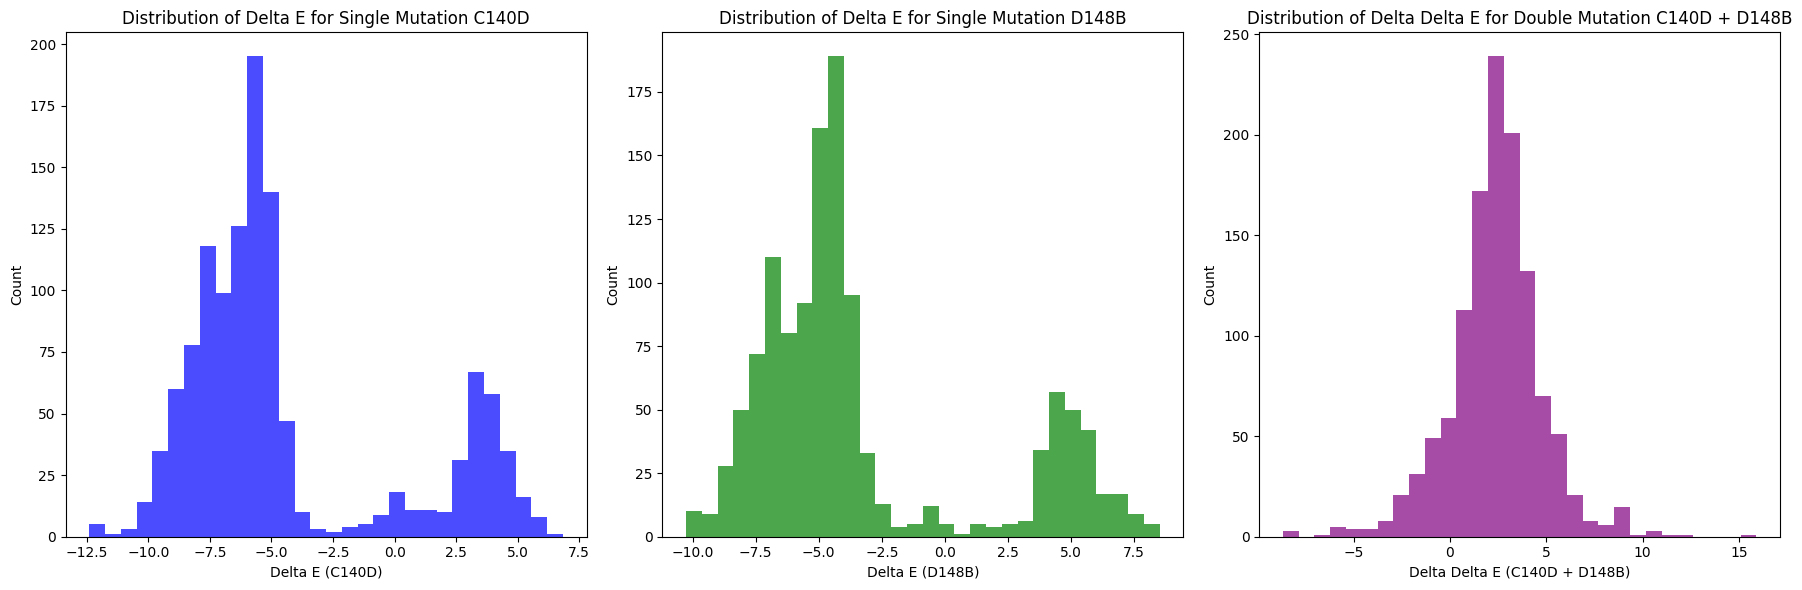

In [ ]:
import matplotlib.pyplot as plt

# Calculate delta E for single mutation C140D
delta_e_c140d = []
for seq in sequence_list:
    delta_e = 0
    for other_pos in range(1, 264):
        if other_pos == 140:
            continue
        other_aa = seq[other_pos - 1]
        delta_e += J_dict.get((140, other_pos, 'C', other_aa), 0) - J_dict.get((140, other_pos, 'D', other_aa), 0)
    delta_e_c140d.append(delta_e)

# Calculate delta E for single mutation D148B
delta_e_d148b = []
for seq in sequence_list:
    delta_e = 0
    for other_pos in range(1, 264):
        if other_pos == 148:
            continue
        other_aa = seq[other_pos - 1]
        delta_e += J_dict.get((148, other_pos, 'D', other_aa), 0) - J_dict.get((148, other_pos, 'B', other_aa), 0)
    delta_e_d148b.append(delta_e)

# Calculate delta delta E for double mutation C140D and D148B
delta_delta_e_c140d_d148b = []
for seq in sequence_list:
    delta_delta_e = double_mutation_delta_delta_E(seq, 140, 'C', 148, 'B', J_dict, 'D', 'D')
    delta_delta_e_c140d_d148b.append(delta_delta_e)

# Plot the distributions side by side
plt.figure(figsize=(18, 6))

# Plot for single mutation C140D
plt.subplot(1, 3, 1)
plt.hist(delta_e_c140d, bins=30, color='blue', alpha=0.7)
plt.xlabel('Delta E (C140D)')
plt.ylabel('Count')
plt.title('Distribution of Delta E for Single Mutation C140D')

# Plot for single mutation D148B
plt.subplot(1, 3, 2)
plt.hist(delta_e_d148b, bins=30, color='green', alpha=0.7)
plt.xlabel('Delta E (D148B)')
plt.ylabel('Count')
plt.title('Distribution of Delta E for Single Mutation D148B')

# Plot for double mutation C140D and D148B
plt.subplot(1, 3, 3)
plt.hist(delta_delta_e_c140d_d148b, bins=30, color='purple', alpha=0.7)
plt.xlabel('Delta Delta E (C140D + D148B)')
plt.ylabel('Count')
plt.title('Distribution of Delta Delta E for Double Mutation C140D + D148B')

plt.tight_layout()
plt.show()

also do one hot enocidng for all three sets and show top, bottom , middle as well as backgrounds

instead of one hot  encoding, also put the vector's weight into encoding, the weight is defined as the averae of that position that amino acid react iwth other amino acid average, and also encode the standard diviation of the energy for that aa react with other aa at that position 

In [ ]:
# Calculate the average and standard deviation of interaction energies for each amino acid at each position
aa_stats = {aa: {'mean': [0] * 263, 'std': [0] * 263} for aa in amino_acids}

for pos in range(1, 264):
    for aa in amino_acids:
        interaction_energies = [
            J_dict.get((pos, other_pos, aa, other_aa), 0)
            for other_pos in range(1, 264) if other_pos != pos
            for other_aa in amino_acids
        ]
        aa_stats[aa]['mean'][pos - 1] = np.mean(interaction_energies)
        aa_stats[aa]['std'][pos - 1] = np.std(interaction_energies)

# Encode sequences with weights (mean and std) for each amino acid at each position
weighted_encoded_sequences = []
for seq in sequence_list:
    weighted_encoding = []
    for pos, aa in enumerate(seq):
        weighted_encoding.append(aa_stats[aa]['mean'][pos])  # Add mean
        weighted_encoding.append(aa_stats[aa]['std'][pos])   # Add std
    weighted_encoded_sequences.append(weighted_encoding)

# Convert to numpy array
X_weighted = np.array(weighted_encoded_sequences)

# Print the shape of the new encoded feature matrix
print(f"Shape of weighted encoded feature matrix: {X_weighted.shape}")

Shape of weighted encoded feature matrix: (1220, 526)


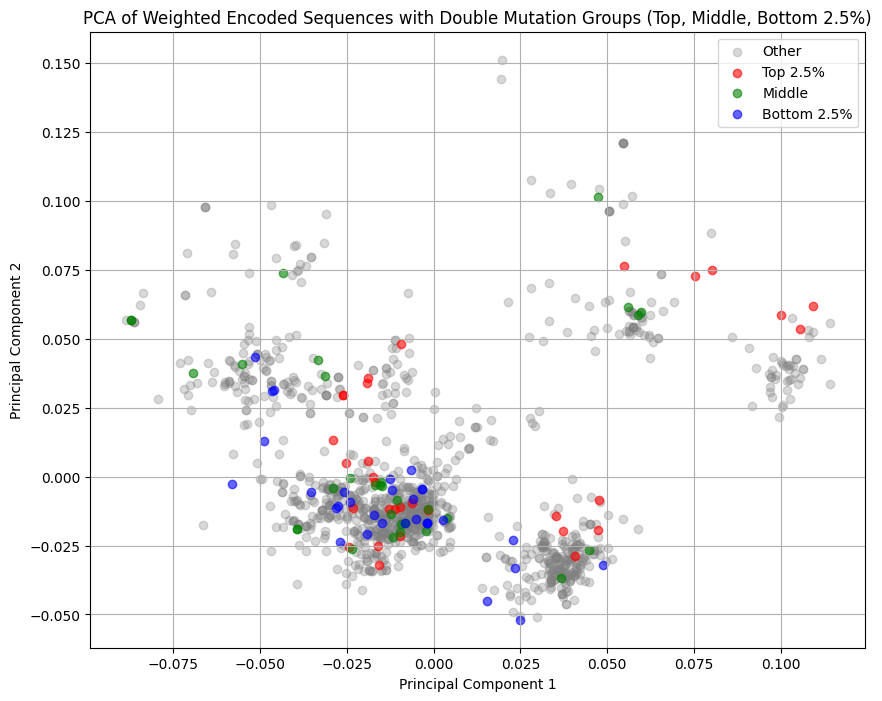

In [ ]:
from sklearn.decomposition import PCA
import numpy as np

import matplotlib.pyplot as plt

# Perform PCA on the weighted encoding
pca = PCA(n_components=2)
X_pca_weighted = pca.fit_transform(X_weighted)

# Identify the three categories of double mutation
# Top 2.5%, middle, and bottom 2.5% indexes are already defined
labels_weighted = np.full(len(sequence_list), -1, dtype=int)  # Default label for other sequences
labels_weighted[top_2_5_indexes] = 0  # Label for top 2.5%
labels_weighted[middle_indexes] = 1   # Label for middle
labels_weighted[bottom_2_5_indexes] = 2  # Label for bottom 2.5%

# Define colors and labels for plotting
colors = ['red', 'green', 'blue', 'gray']  # Gray for other sequences
group_labels = ['Top 2.5%', 'Middle', 'Bottom 2.5%', 'Other']

# Plot the PCA results
plt.figure(figsize=(10, 8))

# Plot the 'Other' points first as background
plt.scatter(X_pca_weighted[labels_weighted == -1, 0], X_pca_weighted[labels_weighted == -1, 1], 
            c=colors[3], label=group_labels[3], alpha=0.3)

# Plot the specific groups
for i in range(3):
    plt.scatter(X_pca_weighted[labels_weighted == i, 0], X_pca_weighted[labels_weighted == i, 1], 
                c=colors[i], label=group_labels[i], alpha=0.6)

# Add labels, title, and legend
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA of Weighted Encoded Sequences with Double Mutation Groups (Top, Middle, Bottom 2.5%)')
plt.legend()
plt.grid(True)
plt.show()